# Do IHs Extract Output Identity or Input-Output Mappings?

**Hypothesis 1:** IHs extract the output word's identity (pushing toward a generic answer subspace).
**Hypothesis 2:** IHs extract something about how the input becomes the output.

**Test A (most direct):** Same output word paired with different inputs. Apply OV circuit.
If the OV outputs are identical → H1. If they differ → H2.

**Test B:** Scramble input-output pairings in a prompt (same set of output words, wrong pairings).
If accuracy is unchanged → H1. If it drops → H2.

**Test C:** Replace all output words with the SAME word.
If accuracy is maintained → H1 (one word is enough to identify the subspace).
If it drops → the diversity of outputs matters, suggesting more than just subspace ID.

In [1]:
import sys
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import pickle

from transformer_lens import HookedTransformer
from configs import *
from utils import *

random.seed(SEED)
torch.manual_seed(SEED)
%matplotlib inline

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-06 12:19:00.565294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained(
    MODEL_NAME, device=DEVICE,
    dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
)
model.eval()
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
d_head = model.cfg.d_head

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)
tasks = load_hendel_data(HENDEL_REPO)
print(f'{n_layers}L, {n_heads}H, d={d_model}, {len(all_splits)} tasks')

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.09s/it]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
28L, 24H, d=3072, 20 tasks


In [3]:
# Identify output-attending heads
all_prompts_sub = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts'][:5]:
        all_prompts_sub.append(pdata)

attn_to_in, attn_to_out, attn_to_sep = extract_attention_patterns(model, all_prompts_sub)
output_attending_heads = select_top_heads(attn_to_out, percentile=90)
print(f'Output-attending heads (top 10%): {len(output_attending_heads)}')

Attention patterns: 100%|██████████| 100/100 [00:05<00:00, 17.98it/s]

Output-attending heads (top 10%): 68


## Test A: Same output word, different inputs → compare OV outputs

For each task, find cases where the same output word appears with different inputs.
Build two prompts that are identical except for the input paired with the target output.
Extract h at the output position in both, apply OV circuit, compare.

In [6]:
# Find tasks where the same output appears with multiple inputs
# (e.g., country->capital: multiple countries map to the same capital is rare,
# but present->past: multiple present-tense words map to the same past-tense word)
# 
# Alternative approach: for ANY task, build two prompts where demo k has the same output
# but a different input, while all other demos are identical.
# This controls for everything except the input at one position.

RESID_FILTER = lambda name: 'resid_post' in name

def apply_ov_circuit(model, layer, head, vector):
    W_V = model.blocks[layer].attn.W_V[head].detach().cpu().float().numpy()
    W_O = model.blocks[layer].attn.W_O[head].detach().cpu().float().numpy()
    return W_O.T @ (W_V.T @ vector)

In [7]:
# For each task, construct pairs of prompts that differ only in one demo's input.
# Strategy: take a prompt, swap out one demo's input with a different input
# that maps to the SAME output. If no such pair exists in the task,
# swap with any other input (the output word at that position stays the same
# because we're looking at positions, not re-running the task).
#
# Actually simpler: just build two different prompts for the same task.
# Pick a demo position. Both prompts have the same output word at that position
# but different inputs. All other demos are identical.

N_COMPARISONS = 20  # per task

# cosine similarity per (layer, head)
ov_cosine_same_output = defaultdict(list)  # (l, h) -> [cosine similarities]
# also track raw h_label cosine (before OV) as baseline
h_cosine_same_output = defaultdict(list)

for task_name, pairs in tasks.items():
    # Group pairs by output
    by_output = defaultdict(list)
    for inp, out in pairs:
        by_output[out].append(inp)
    
    # Find outputs with at least 2 inputs
    shared_outputs = {out: inps for out, inps in by_output.items() if len(inps) >= 2}
    if not shared_outputs:
        # Fall back: pick any two inputs, use the same output word for both
        # (the output token at that position will be the same regardless)
        all_pairs = list(pairs)
        if len(all_pairs) < N_DEMOS + 2:
            continue
        shared_outputs = {all_pairs[0][1]: [all_pairs[0][0], all_pairs[1][0]]}
    
    comparisons_done = 0
    for target_output, input_list in shared_outputs.items():
        if comparisons_done >= N_COMPARISONS:
            break
        
        for i in range(0, len(input_list) - 1, 2):
            if comparisons_done >= N_COMPARISONS:
                break
            
            input_a = input_list[i]
            input_b = input_list[i + 1]
            
            # Build two prompts: identical demos except demo 0 has different input
            other_pairs = [(inp, out) for inp, out in pairs
                           if inp not in (input_a, input_b)]
            if len(other_pairs) < N_DEMOS:
                continue
            
            shared_demos = random.sample(other_pairs, N_DEMOS - 1)
            query = random.choice(other_pairs)
            
            demos_a = [(input_a, target_output)] + shared_demos
            demos_b = [(input_b, target_output)] + shared_demos
            
            prompt_a = build_icl_prompt(demos_a, query[0])
            prompt_b = build_icl_prompt(demos_b, query[0])
            
            tokens_a = model.to_tokens(prompt_a, prepend_bos=True)
            tokens_b = model.to_tokens(prompt_b, prepend_bos=True)
            
            per_demo_a = find_per_demo_positions(model, prompt_a, demos_a)
            per_demo_b = find_per_demo_positions(model, prompt_b, demos_b)
            
            # The target output is at demo 0's output position
            out_pos_a = per_demo_a[0]['output_positions']
            out_pos_b = per_demo_b[0]['output_positions']
            if not out_pos_a or not out_pos_b:
                continue
            
            with torch.no_grad():
                _, cache_a = model.run_with_cache(tokens_a, names_filter=RESID_FILTER)
                _, cache_b = model.run_with_cache(tokens_b, names_filter=RESID_FILTER)
            
            for l, h in output_attending_heads:
                h_a = cache_a['resid_post', l][0, out_pos_a[0]].cpu().float().numpy()
                h_b = cache_b['resid_post', l][0, out_pos_b[0]].cpu().float().numpy()
                
                # Cosine of raw hidden states
                cos_h = np.dot(h_a, h_b) / (np.linalg.norm(h_a) * np.linalg.norm(h_b) + 1e-10)
                h_cosine_same_output[(l, h)].append(cos_h)
                
                # Apply OV circuit
                ov_a = apply_ov_circuit(model, l, h, h_a)
                ov_b = apply_ov_circuit(model, l, h, h_b)
                
                cos_ov = np.dot(ov_a, ov_b) / (np.linalg.norm(ov_a) * np.linalg.norm(ov_b) + 1e-10)
                ov_cosine_same_output[(l, h)].append(cos_ov)
            
            del cache_a, cache_b
            torch.cuda.empty_cache()
            comparisons_done += 1
    
    print(f'{task_name}: {comparisons_done} comparisons')

print(f'\nDone. {len(ov_cosine_same_output)} heads.')

knowledge/country_capital: 20 comparisons
knowledge/football_player_position: 20 comparisons
knowledge/location_continent: 20 comparisons
knowledge/location_country: 20 comparisons
knowledge/location_language: 20 comparisons
knowledge/location_religion: 20 comparisons
knowledge/person_language: 20 comparisons
knowledge/person_profession: 20 comparisons
linguistic/antonyms: 8 comparisons
linguistic/plural_singular: 1 comparisons
linguistic/present_simple_gerund: 1 comparisons
linguistic/present_simple_past_perfect: 1 comparisons
linguistic/present_simple_past_simple: 1 comparisons
linguistic/singular_plural: 1 comparisons
translation/en_es: 20 comparisons
translation/en_fr: 20 comparisons
translation/en_it: 20 comparisons
translation/es_en: 1 comparisons
translation/fr_en: 1 comparisons
translation/it_en: 1 comparisons

Done. 68 heads.


In [8]:
# Results: if cosine ≈ 1, the OV output is the same regardless of input → H1
# If cosine < 1, the input affected the OV output → H2

mean_h_cos = {k: np.mean(v) for k, v in h_cosine_same_output.items()}
mean_ov_cos = {k: np.mean(v) for k, v in ov_cosine_same_output.items()}

all_h = list(mean_h_cos.values())
all_ov = list(mean_ov_cos.values())

print(f'Same output word, different input:')
print(f'  Raw h_label cosine:  {np.mean(all_h):.4f} ± {np.std(all_h):.4f}')
print(f'  After OV circuit:    {np.mean(all_ov):.4f} ± {np.std(all_ov):.4f}')
print()
if np.mean(all_ov) > np.mean(all_h):
    print('OV circuit INCREASES similarity → strips away input-specific info → supports H1')
else:
    print('OV circuit DECREASES or preserves difference → input info survives → supports H2')

Same output word, different input:
  Raw h_label cosine:  0.8738 ± 0.0365
  After OV circuit:    0.8664 ± 0.0721

OV circuit DECREASES or preserves difference → input info survives → supports H2


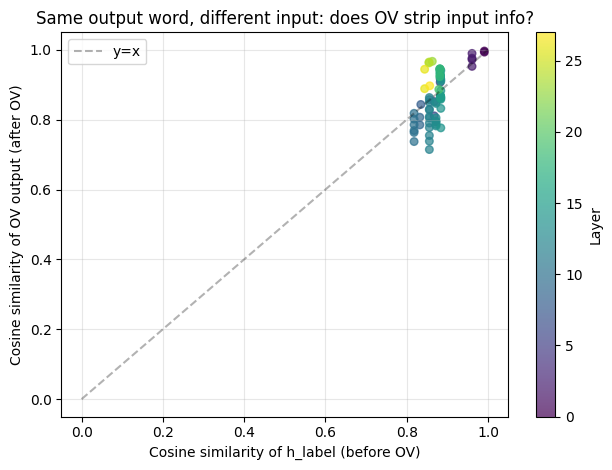

In [9]:
# Scatter: raw h cosine vs OV cosine, colored by layer
sorted_heads = sorted(mean_h_cos.keys())
h_vals = [mean_h_cos[k] for k in sorted_heads]
ov_vals = [mean_ov_cos[k] for k in sorted_heads]
layer_vals = [l for l, h in sorted_heads]

fig, ax = plt.subplots()
sc = ax.scatter(h_vals, ov_vals, c=layer_vals, cmap='viridis', alpha=0.7, s=30)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel('Cosine similarity of h_label (before OV)')
ax.set_ylabel('Cosine similarity of OV output (after OV)')
ax.set_title('Same output word, different input: does OV strip input info?')
plt.colorbar(sc, label='Layer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

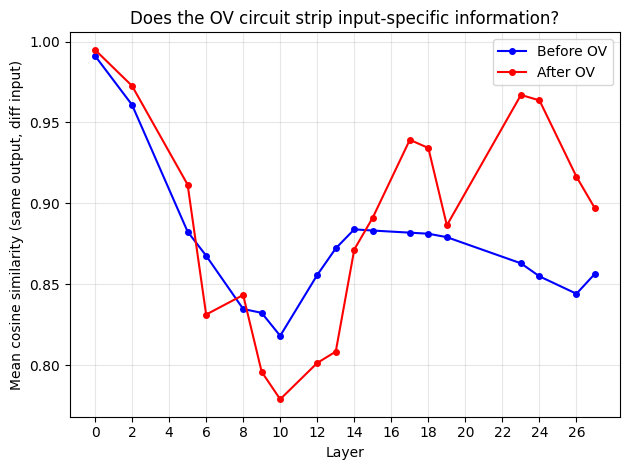

In [10]:
# Per-layer summary
layer_h = defaultdict(list)
layer_ov = defaultdict(list)
for (l, h) in sorted_heads:
    layer_h[l].append(mean_h_cos[(l, h)])
    layer_ov[l].append(mean_ov_cos[(l, h)])

fig, ax = plt.subplots()
layers_present = sorted(layer_h.keys())
ax.plot(layers_present, [np.mean(layer_h[l]) for l in layers_present], 'b-o', label='Before OV', ms=4)
ax.plot(layers_present, [np.mean(layer_ov[l]) for l in layers_present], 'r-o', label='After OV', ms=4)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean cosine similarity (same output, diff input)')
ax.set_title('Does the OV circuit strip input-specific information?')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
plt.tight_layout()
plt.show()

## Test B: Scramble input-output pairings

Take a 10-shot prompt, shuffle which outputs go with which inputs.
The set of output words is identical — only the pairings change.

Extract task vector from final arrow, patch into zero-shot, measure accuracy.

H1 predicts: no change (same output words → same push toward answer subspace).
H2 predicts: accuracy drops (wrong pairings → wrong mappings extracted).

In [12]:
import time

N_PROMPTS = 10
RESID_FILTER = lambda name: 'resid_post' in name

# original vs scrambled accuracy at each layer
orig_accs = defaultdict(list)  # layer -> [0/1]
scrambled_accs = defaultdict(list)

t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        # Original prompt
        prompt_orig = pdata['prompt']
        
        # Scrambled: shuffle inputs while keeping outputs fixed
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        last_orig = tokens_orig.shape[1] - 1
        last_scram = tokens_scram.shape[1] - 1
        
        for layer in range(n_layers):
            theta_orig = cache_orig['resid_post', layer][0, last_orig].cpu().float().numpy()
            theta_scram = cache_scram['resid_post', layer][0, last_scram].cpu().float().numpy()
            
            logits_orig = eval_patched_resid(model, eq['zs_prompt'], theta_orig, layer)
            logits_scram = eval_patched_resid(model, eq['zs_prompt'], theta_scram, layer)
            
            orig_accs[layer].append(float(check_correct(model, logits_orig, eq['query_output'])))
            scrambled_accs[layer].append(float(check_correct(model, logits_scram, eq['query_output'])))
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 551s


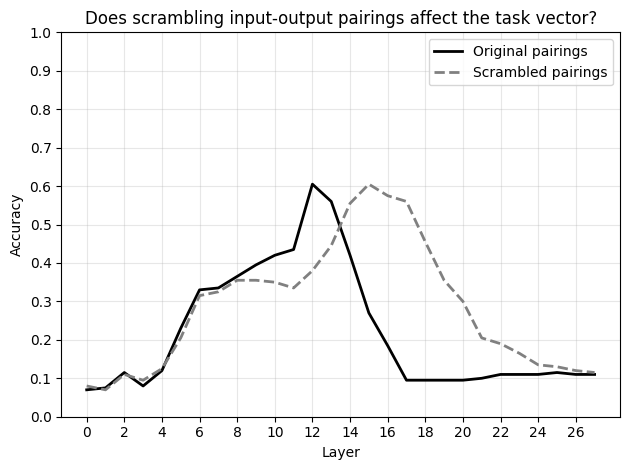

Original peak: 0.605 at layer 12
Scrambled peak: 0.605 at layer 15
Difference: 0.000


In [21]:
# Plot: original vs scrambled
layers = list(range(n_layers))
orig_curve = [np.mean(orig_accs[l]) for l in layers]
scram_curve = [np.mean(scrambled_accs[l]) for l in layers]

fig, ax = plt.subplots()
ax.plot(layers, orig_curve, c='black', ms=4, lw=2, label='Original pairings')
ax.plot(layers, scram_curve, c='gray', ls='--', ms=4, lw=2, label='Scrambled pairings')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Does scrambling input-output pairings affect the task vector?')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Original peak: {max(orig_curve):.3f} at layer {np.argmax(orig_curve)}')
print(f'Scrambled peak: {max(scram_curve):.3f} at layer {np.argmax(scram_curve)}')
print(f'Difference: {max(orig_curve) - max(scram_curve):.3f}')

In [22]:
# Compare IH outputs between original and scrambled prompts
# Extract hook_z at final position for each IH, compute cosine similarity

HEAD_Z_FILTER = lambda name: 'hook_z' in name

ih_cosines = defaultdict(list)  # (layer, head) -> [cosine per prompt]

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        # Original
        prompt_orig = pdata['prompt']
        
        # Scrambled (same as before: shuffle inputs, keep outputs fixed)
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        last_orig = tokens_orig.shape[1] - 1
        last_scram = tokens_scram.shape[1] - 1
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=HEAD_Z_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=HEAD_Z_FILTER)
        
        for l, h in output_attending_heads:
            z_orig = cache_orig[f'blocks.{l}.attn.hook_z'][0, last_orig, h].cpu().float().numpy()
            z_scram = cache_scram[f'blocks.{l}.attn.hook_z'][0, last_scram, h].cpu().float().numpy()
            cos = np.dot(z_orig, z_scram) / (np.linalg.norm(z_orig) * np.linalg.norm(z_scram) + 1e-10)
            ih_cosines[(l, h)].append(cos)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()

print(f'Done. {len(ih_cosines)} heads.')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done. 68 heads.


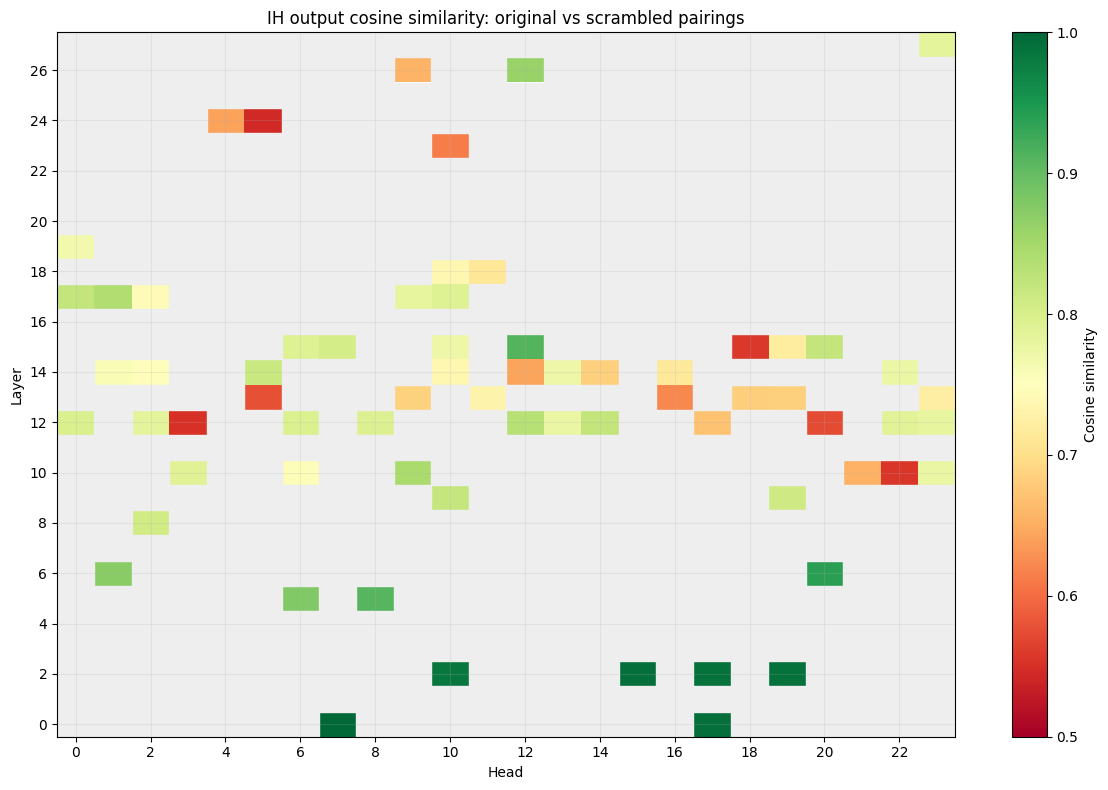

In [26]:
# Heatmap: layer x head, color = mean cosine similarity
cos_grid = np.full((n_layers, n_heads), np.nan)
for (l, h), c in mean_cos.items():
    cos_grid[l, h] = c

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(cos_grid, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0, origin='lower')
ax.set_xlabel('Head')
ax.set_ylabel('Layer')
ax.set_title('IH output cosine similarity: original vs scrambled pairings')
plt.colorbar(im, ax=ax, label='Cosine similarity')

# Mark non-IH cells as gray
for l in range(n_layers):
    for h in range(n_heads):
        if np.isnan(cos_grid[l, h]):
            ax.add_patch(plt.Rectangle((h-0.5, l-0.5), 1, 1, fill=True, color='#eeeeee'))

ax.set_xticks(range(0, n_heads, 2))
ax.set_yticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [27]:
# PCA on IH outputs: original vs scrambled
from sklearn.decomposition import PCA

HEAD_Z_FILTER = lambda name: 'hook_z' in name

# Pick a few heads to visualize individually
example_heads = sorted(output_attending_heads)[:6]  # first 6 by layer

# Collect: per head, list of OV outputs labeled original/scrambled
head_outputs = {(l,h): {'orig': [], 'scram': []} for l, h in example_heads}

for task_name, splits in all_splits.items():
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        
        prompt_orig = pdata['prompt']
        prompt_scram = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scram, prepend_bos=True)
        
        with torch.no_grad():
            _, cache_o = model.run_with_cache(tokens_orig, names_filter=HEAD_Z_FILTER)
            _, cache_s = model.run_with_cache(tokens_scram, names_filter=HEAD_Z_FILTER)
        
        for l, h in example_heads:
            z_o = cache_o[f'blocks.{l}.attn.hook_z'][0, -1, h].cpu().float().numpy()
            z_s = cache_s[f'blocks.{l}.attn.hook_z'][0, -1, h].cpu().float().numpy()
            W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
            head_outputs[(l,h)]['orig'].append(W_O.T @ z_o)
            head_outputs[(l,h)]['scram'].append(W_O.T @ z_s)
        
        del cache_o, cache_s
        torch.cuda.empty_cache()

print(f'Collected {len(head_outputs[(example_heads[0])[0], (example_heads[0])[1]]["orig"])} samples per head')

Collected 200 samples per head


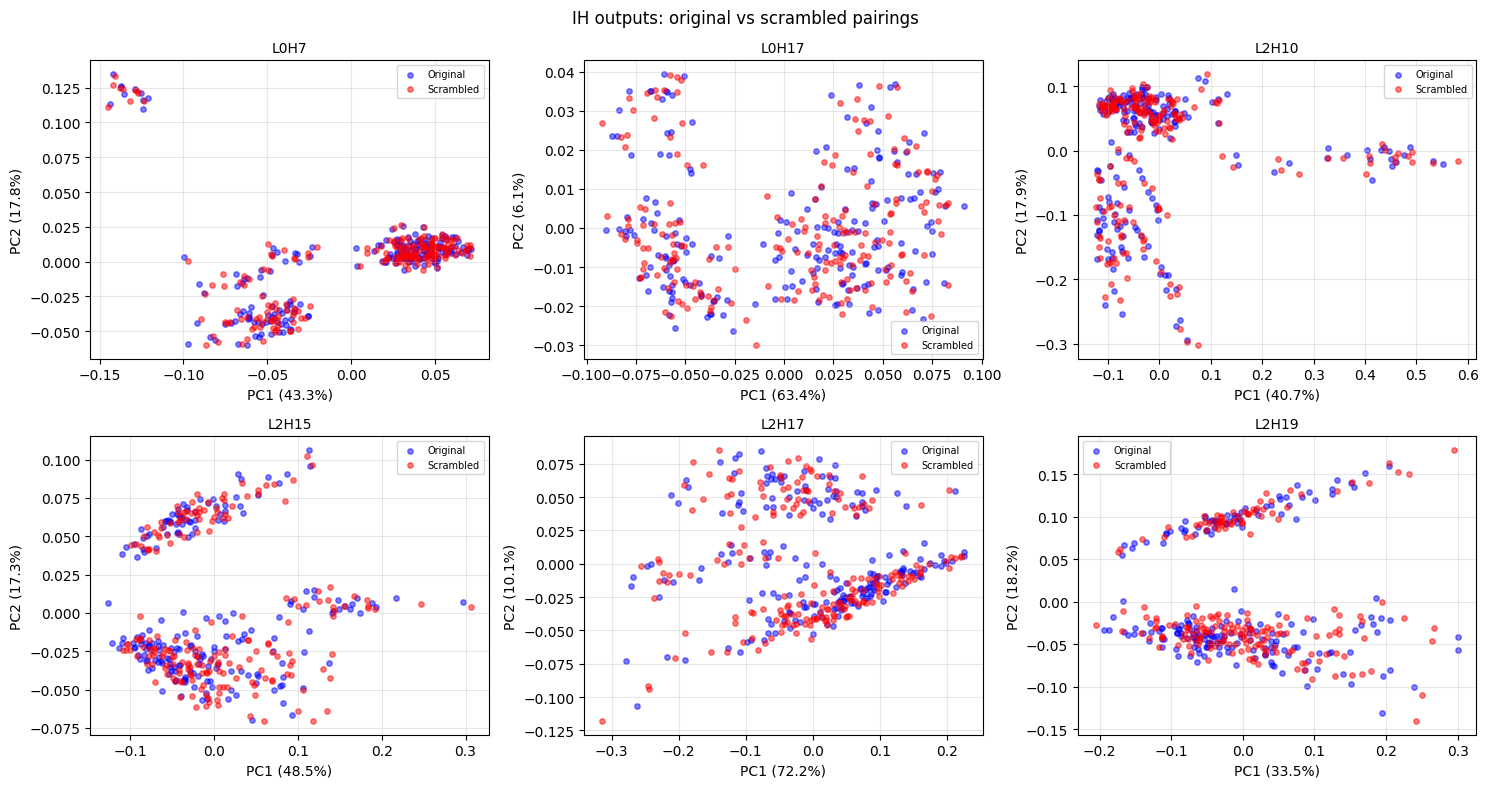

In [28]:
# PCA plot: one subplot per head
n_cols = 3
n_rows = (len(example_heads) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (l, h) in enumerate(example_heads):
    ax = axes[idx]
    orig = np.stack(head_outputs[(l,h)]['orig'])
    scram = np.stack(head_outputs[(l,h)]['scram'])
    
    combined = np.vstack([orig, scram])
    pca = PCA(n_components=2)
    proj = pca.fit_transform(combined)
    
    n = len(orig)
    ax.scatter(proj[:n, 0], proj[:n, 1], alpha=0.5, s=15, label='Original', c='blue')
    ax.scatter(proj[n:, 0], proj[n:, 1], alpha=0.5, s=15, label='Scrambled', c='red')
    ax.set_title(f'L{l}H{h}', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var[1]:.1%})')

for idx in range(len(example_heads), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('IH outputs: original vs scrambled pairings', fontsize=12)
plt.tight_layout()
plt.show()

## Test C: Replace all outputs with the same word

Every demo has the same output word (e.g., always 'hello' regardless of input).
The model sees: שלום → hello, תודה → hello, בוקר → hello, ...

H1 predicts: still works — 'hello' is still English, model gets pushed to English subspace.
H2 predicts: fails — no meaningful input-output mapping to extract.

In [14]:
# For each task, pick the most common output word and replace all outputs with it
uniform_accs = defaultdict(list)  # layer -> [0/1]

t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    
    # Find most common output
    all_outputs = [out for _, out in tasks[task_name]]
    from collections import Counter
    most_common_output = Counter(all_outputs).most_common(1)[0][0]
    
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}: all outputs → "{most_common_output}"')
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        # Replace all outputs with the same word
        demos_uniform = [(inp, most_common_output) for inp, _ in demos]
        prompt_uniform = build_icl_prompt(demos_uniform, query_input)
        
        tokens = model.to_tokens(prompt_uniform, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        for layer in range(n_layers):
            theta = cache['resid_post', layer][0, last_pos].cpu().float().numpy()
            logits = eval_patched_resid(model, eq['zs_prompt'], theta, layer)
            uniform_accs[layer].append(float(check_correct(model, logits, eq['query_output'])))
        
        del cache
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital: all outputs → "Paris"
[2/20] knowledge/football_player_position: all outputs → "midfielder"
[3/20] knowledge/location_continent: all outputs → "Antarctica"
[4/20] knowledge/location_country: all outputs → "Pennsylvania"
[5/20] knowledge/location_language: all outputs → "Finnish"
[6/20] knowledge/location_religion: all outputs → "Muslim"
[7/20] knowledge/person_language: all outputs → "English"
[8/20] knowledge/person_profession: all outputs → "actor"
[9/20] linguistic/antonyms: all outputs → "light"
[10/20] linguistic/plural_singular: all outputs → "addendum"
[11/20] linguistic/present_simple_gerund: all outputs → "singing"
[12/20] linguistic/present_simple_past_perfect: all outputs → "awoken"
[13/20] linguistic/present_simple_past_simple: all outputs → "acknowledged"
[14/20] linguistic/singular_plural: all outputs → "media"
[15/20] translation/en_es: all outputs → "en"
[16/20] translation/en_fr: all outputs → "dans"
[17/20] translation/en_it: all outp

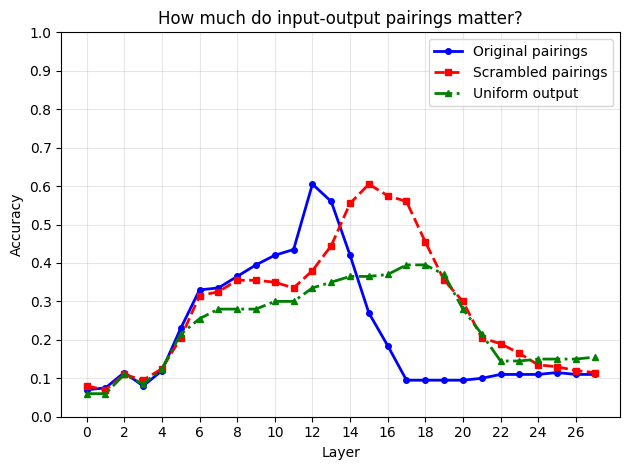

Original peak:  0.605 at layer 12
Scrambled peak: 0.605 at layer 15
Uniform peak:   0.395 at layer 17


In [15]:
# Plot: original vs scrambled vs uniform
uniform_curve = [np.mean(uniform_accs[l]) for l in layers]

fig, ax = plt.subplots()
ax.plot(layers, orig_curve, 'b-o', ms=4, lw=2, label='Original pairings')
ax.plot(layers, scram_curve, 'r--s', ms=4, lw=2, label='Scrambled pairings')
ax.plot(layers, uniform_curve, 'g-.^', ms=4, lw=2, label='Uniform output')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('How much do input-output pairings matter?')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Original peak:  {max(orig_curve):.3f} at layer {np.argmax(orig_curve)}')
print(f'Scrambled peak: {max(scram_curve):.3f} at layer {np.argmax(scram_curve)}')
print(f'Uniform peak:   {max(uniform_curve):.3f} at layer {np.argmax(uniform_curve)}')

In [16]:
# Save all results
results = {
    'ov_cosine_same_output': {str(k): v for k, v in ov_cosine_same_output.items()},
    'h_cosine_same_output': {str(k): v for k, v in h_cosine_same_output.items()},
    'orig_accs': dict(orig_accs),
    'scrambled_accs': dict(scrambled_accs),
    'uniform_accs': dict(uniform_accs),
}
with open('h1_test_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved h1_test_results.pkl')

Saved h1_test_results.pkl


## More tests

In [29]:
# Measure LRH: for each task, compute mean cosine similarity between
# input and output token embeddings. High cosine → LRH plausible.
 
W_E = model.W_E.detach().cpu().float()  # [vocab, d_model]
 
lrh_scores = {}
for task_name, pairs in tasks.items():
    cosines = []
    for inp, out in pairs:
        inp_tok = model.to_tokens(inp, prepend_bos=False)[0]
        out_tok = model.to_tokens(out, prepend_bos=False)[0]
        # Use first token of each (most are single-token)
        e_in = W_E[inp_tok[0]].numpy()
        e_out = W_E[out_tok[0]].numpy()
        cos = np.dot(e_in, e_out) / (np.linalg.norm(e_in) * np.linalg.norm(e_out) + 1e-10)
        cosines.append(cos)
    lrh_scores[task_name] = np.mean(cosines)
 
# Print sorted
print(f'{"Task":<45s}  {"LRH (cos)":>8s}')
print('-' * 56)
for t in sorted(lrh_scores, key=lrh_scores.get):
    print(f'{t:<45s}  {lrh_scores[t]:>8.4f}')
 
# Split at median
median_lrh = np.median(list(lrh_scores.values()))
lrh_high = {t for t, s in lrh_scores.items() if s >= median_lrh}
lrh_low = {t for t, s in lrh_scores.items() if s < median_lrh}
print(f'\nMedian LRH: {median_lrh:.4f}')
print(f'LRH-high tasks ({len(lrh_high)}): {sorted(lrh_high)}')
print(f'LRH-low tasks  ({len(lrh_low)}): {sorted(lrh_low)}')

Task                                           LRH (cos)
--------------------------------------------------------
knowledge/football_player_position               0.0590
knowledge/person_profession                      0.0608
knowledge/location_continent                     0.0990
knowledge/location_religion                      0.1137
knowledge/person_language                        0.1258
linguistic/antonyms                              0.1756
knowledge/location_language                      0.1793
translation/en_it                                0.1916
translation/it_en                                0.1949
translation/es_en                                0.1994
translation/en_es                                0.2057
translation/fr_en                                0.2133
knowledge/location_country                       0.2267
translation/en_fr                                0.2303
knowledge/country_capital                        0.2586
linguistic/present_simple_past_perfect        

In [30]:
import time
 
N_PROMPTS = 10
RESID_FILTER = lambda name: 'resid_post' in name
 
# Track per-task, per-layer accuracy
orig_per_task = defaultdict(lambda: defaultdict(list))    # task -> layer -> [0/1]
scram_per_task = defaultdict(lambda: defaultdict(list))
 
t_start = time.time()
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        # Scrambled: shuffle inputs, keep outputs fixed
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        last_orig = tokens_orig.shape[1] - 1
        last_scram = tokens_scram.shape[1] - 1
        
        for layer in range(n_layers):
            theta_orig = cache_orig['resid_post', layer][0, last_orig].cpu().float().numpy()
            theta_scram = cache_scram['resid_post', layer][0, last_scram].cpu().float().numpy()
            
            logits_orig = eval_patched_resid(model, eq['zs_prompt'], theta_orig, layer)
            logits_scram = eval_patched_resid(model, eq['zs_prompt'], theta_scram, layer)
            
            c_orig = float(check_correct(model, logits_orig, eq['query_output']))
            c_scram = float(check_correct(model, logits_scram, eq['query_output']))
            
            orig_per_task[task_name][layer].append(c_orig)
            scram_per_task[task_name][layer].append(c_scram)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
 
print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 459s


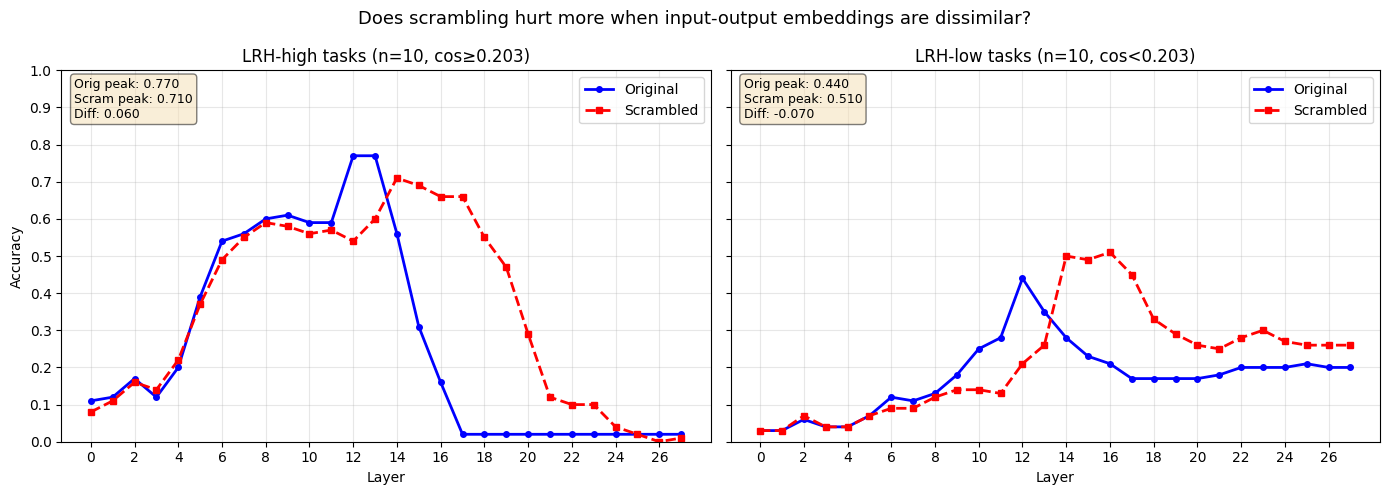

In [31]:
layers = list(range(n_layers))
 
def group_curve(per_task_dict, task_set, layers):
    """Average accuracy across tasks in task_set, per layer."""
    curve = []
    for l in layers:
        vals = []
        for t in task_set:
            if t in per_task_dict:
                vals.extend(per_task_dict[t][l])
        curve.append(np.mean(vals) if vals else 0)
    return curve
 
orig_high = group_curve(orig_per_task, lrh_high, layers)
scram_high = group_curve(scram_per_task, lrh_high, layers)
orig_low = group_curve(orig_per_task, lrh_low, layers)
scram_low = group_curve(scram_per_task, lrh_low, layers)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
ax = axes[0]
ax.plot(layers, orig_high, 'b-o', ms=4, lw=2, label='Original')
ax.plot(layers, scram_high, 'r--s', ms=4, lw=2, label='Scrambled')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title(f'LRH-high tasks (n={len(lrh_high)}, cos≥{median_lrh:.3f})')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
peak_oh = max(orig_high)
peak_sh = max(scram_high)
ax.text(0.02, 0.98, f'Orig peak: {peak_oh:.3f}\nScram peak: {peak_sh:.3f}\nDiff: {peak_oh - peak_sh:.3f}',
        transform=ax.transAxes, va='top', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
ax = axes[1]
ax.plot(layers, orig_low, 'b-o', ms=4, lw=2, label='Original')
ax.plot(layers, scram_low, 'r--s', ms=4, lw=2, label='Scrambled')
ax.set_xlabel('Layer')
ax.set_title(f'LRH-low tasks (n={len(lrh_low)}, cos<{median_lrh:.3f})')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
peak_ol = max(orig_low)
peak_sl = max(scram_low)
ax.text(0.02, 0.98, f'Orig peak: {peak_ol:.3f}\nScram peak: {peak_sl:.3f}\nDiff: {peak_ol - peak_sl:.3f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
fig.suptitle('Does scrambling hurt more when input-output embeddings are dissimilar?', fontsize=13)
plt.tight_layout()
plt.show()

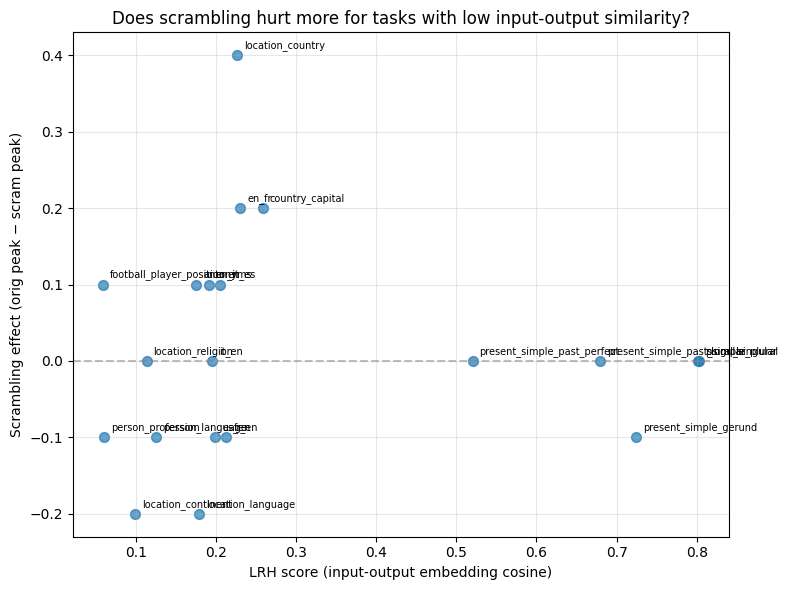

Pearson r = -0.039, p = 0.8693
Positive r → scrambling hurts MORE for LRH-high tasks (unexpected)
Negative r → scrambling hurts MORE for LRH-low tasks (predicted by TR story)


In [32]:
# Scatter: x = LRH score, y = scrambling effect (orig peak - scram peak)
task_names_sorted = sorted(lrh_scores.keys())
lrh_vals = [lrh_scores[t] for t in task_names_sorted]
scram_effects = []
for t in task_names_sorted:
    orig_curve_t = [np.mean(orig_per_task[t][l]) for l in layers]
    scram_curve_t = [np.mean(scram_per_task[t][l]) for l in layers]
    scram_effects.append(max(orig_curve_t) - max(scram_curve_t))
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(lrh_vals, scram_effects, s=50, alpha=0.7)
for i, t in enumerate(task_names_sorted):
    short = t.split('/')[-1]
    ax.annotate(short, (lrh_vals[i], scram_effects[i]), fontsize=7, 
                xytext=(5, 5), textcoords='offset points')
 
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('LRH score (input-output embedding cosine)')
ax.set_ylabel('Scrambling effect (orig peak − scram peak)')
ax.set_title('Does scrambling hurt more for tasks with low input-output similarity?')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Correlation
from scipy import stats
r, p = stats.pearsonr(lrh_vals, scram_effects)
print(f'Pearson r = {r:.3f}, p = {p:.4f}')
print(f'Positive r → scrambling hurts MORE for LRH-high tasks (unexpected)')
print(f'Negative r → scrambling hurts MORE for LRH-low tasks (predicted by TR story)')

In [33]:
print(f'{"Task":<40s}  {"LRH":>6s}  {"Orig":>6s}  {"Scram":>6s}  {"Diff":>6s}')
print('-' * 68)
for t in sorted(task_names_sorted, key=lambda t: lrh_scores[t]):
    orig_c = [np.mean(orig_per_task[t][l]) for l in layers]
    scram_c = [np.mean(scram_per_task[t][l]) for l in layers]
    po, ps = max(orig_c), max(scram_c)
    print(f'{t:<40s}  {lrh_scores[t]:>6.3f}  {po:>6.3f}  {ps:>6.3f}  {po-ps:>+6.3f}')
 

Task                                         LRH    Orig   Scram    Diff
--------------------------------------------------------------------
knowledge/football_player_position         0.059   0.400   0.300  +0.100
knowledge/person_profession                0.061   0.300   0.400  -0.100
knowledge/location_continent               0.099   0.500   0.700  -0.200
knowledge/location_religion                0.114   0.600   0.600  +0.000
knowledge/person_language                  0.126   0.400   0.500  -0.100
linguistic/antonyms                        0.176   0.600   0.500  +0.100
knowledge/location_language                0.179   0.600   0.800  -0.200
translation/en_it                          0.192   0.700   0.600  +0.100
translation/it_en                          0.195   0.700   0.700  +0.000
translation/es_en                          0.199   0.700   0.800  -0.100
translation/en_es                          0.206   0.900   0.800  +0.100
translation/fr_en                          0.213   0.60

In [35]:
# We need words that are reliably single-token in Llama-3.2-3B.
# Strategy: try a large set of common words, keep only single-token ones.
 
candidate_words = [
    # Animals
    'cat', 'dog', 'bird', 'fish', 'horse', 'bear', 'wolf', 'deer', 'fox', 'frog',
    'ant', 'bee', 'cow', 'pig', 'rat', 'bat', 'hen', 'owl', 'ape', 'ram',
    # Colors
    'red', 'blue', 'green', 'black', 'white', 'gold', 'pink', 'gray', 'brown', 'dark',
    # Objects
    'chair', 'table', 'lamp', 'door', 'wall', 'roof', 'book', 'pen', 'cup', 'box',
    'key', 'ring', 'ball', 'bell', 'drum', 'flag', 'coin', 'rope', 'nail', 'seed',
    # Food
    'bread', 'rice', 'milk', 'salt', 'meat', 'cake', 'wine', 'soup', 'corn', 'bean',
    'egg', 'pie', 'jam', 'nut', 'tea', 'fig', 'ham', 'rum', 'ale', 'gin',
    # Nature
    'tree', 'rock', 'rain', 'snow', 'wind', 'fire', 'lake', 'hill', 'sand', 'dust',
    'mud', 'ice', 'fog', 'sun', 'moon', 'star', 'sky', 'sea', 'bay', 'oak',
    # Body
    'hand', 'foot', 'arm', 'leg', 'eye', 'ear', 'lip', 'jaw', 'rib', 'hip',
    # Abstract
    'love', 'fear', 'hope', 'joy', 'pain', 'rage', 'calm', 'fate', 'luck', 'risk',
    # Actions (as nouns/short words)
    'run', 'jump', 'fall', 'swim', 'sing', 'burn', 'drop', 'pull', 'push', 'turn',
    # Numbers/misc
    'one', 'two', 'six', 'ten', 'half', 'pair', 'both', 'each', 'last', 'next',
]
 
# Filter to single-token words (without leading space — we want " word" to be one token)
single_token_words = []
for w in candidate_words:
    # In Llama tokenizer, words in context get a leading space
    toks = model.to_tokens(' ' + w, prepend_bos=False)[0]
    if len(toks) == 1:
        single_token_words.append(w)
 
print(f'{len(single_token_words)} / {len(candidate_words)} words are single-token')
print(f'Words: {single_token_words[:20]}...')
 
# Verify we have enough for our synthetic tasks
assert len(single_token_words) >= 40, f'Need at least 40 single-token words, got {len(single_token_words)}'

130 / 130 words are single-token
Words: ['cat', 'dog', 'bird', 'fish', 'horse', 'bear', 'wolf', 'deer', 'fox', 'frog', 'ant', 'bee', 'cow', 'pig', 'rat', 'bat', 'hen', 'owl', 'ape', 'ram']...


In [36]:
N_SYNTHETIC_TASKS = 10    # number of random tasks
N_PAIRS_PER_TASK = 20     # total pairs per task (10 for demos, rest for eval)
N_DEMOS = 10
N_EVAL = 10
N_PROMPTS_PER_TASK = 10   # different random draws of demos
 
rng = random.Random(42)
 
synthetic_tasks = {}
 
for task_idx in range(N_SYNTHETIC_TASKS):
    # Sample 2 * N_PAIRS_PER_TASK words (inputs from one pool, outputs from another)
    pool = rng.sample(single_token_words, min(2 * N_PAIRS_PER_TASK, len(single_token_words)))
    inputs_pool = pool[:N_PAIRS_PER_TASK]
    outputs_pool = pool[N_PAIRS_PER_TASK:]
    
    # If we don't have enough words, sample with replacement for outputs
    if len(outputs_pool) < N_PAIRS_PER_TASK:
        outputs_pool = [rng.choice(single_token_words) for _ in range(N_PAIRS_PER_TASK)]
    
    # Create arbitrary pairing
    pairs = list(zip(inputs_pool, outputs_pool))
    
    task_name = f'synthetic_{task_idx}'
    synthetic_tasks[task_name] = {
        'all_pairs': pairs,
        'prompts': [],   # will hold (demos, query_input, query_output) tuples
    }
    
    # Generate multiple prompt configurations
    for p_idx in range(N_PROMPTS_PER_TASK):
        rng.shuffle(pairs)
        demo_pairs = pairs[:N_DEMOS]
        eval_pair = pairs[N_DEMOS + (p_idx % (len(pairs) - N_DEMOS))]
        
        synthetic_tasks[task_name]['prompts'].append({
            'demo_pairs': demo_pairs,
            'query_input': eval_pair[0],
            'query_output': eval_pair[1],
        })
 
# Preview
for tname, tdata in list(synthetic_tasks.items())[:3]:
    print(f'{tname}: {tdata["all_pairs"][:5]}...')
    p0 = tdata['prompts'][0]
    print(f'  Demo: {p0["demo_pairs"][:3]}...  Query: {p0["query_input"]} → {p0["query_output"]}')
    print()

synthetic_0: [('table', 'rock'), ('bee', 'drop'), ('tree', 'swim'), ('eye', 'sun'), ('gray', 'bell')]...
  Demo: [('meat', 'cat'), ('fire', 'roof'), ('horse', 'red')]...  Query: ten → salt

synthetic_1: [('pair', 'table'), ('milk', 'owl'), ('jam', 'rice'), ('two', 'drop'), ('leg', 'roof')]...
  Demo: [('pair', 'table'), ('cow', 'pig'), ('deer', 'jump')]...  Query: white → hope

synthetic_2: [('deer', 'seed'), ('drum', 'eye'), ('pig', 'ale'), ('pull', 'coin'), ('door', 'bear')]...
  Demo: [('moon', 'rat'), ('leg', 'lip'), ('love', 'star')]...  Query: half → lamp



In [37]:
# Before testing scrambling, verify the model can learn arbitrary mappings
# from 10-shot ICL. If baseline accuracy is near zero, scrambling test is moot.
 
novel_icl_correct = []
 
for task_name, tdata in synthetic_tasks.items():
    task_correct = []
    for pdata in tdata['prompts']:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        qo = pdata['query_output']
        
        prompt = build_icl_prompt(demos, qi)
        tokens = model.to_tokens(prompt, prepend_bos=True)
        
        with torch.no_grad():
            logits = model(tokens)[0, -1]
        
        correct = float(check_correct(model, logits, qo))
        task_correct.append(correct)
        novel_icl_correct.append(correct)
    
    print(f'{task_name}: {np.mean(task_correct):.3f} ({sum(task_correct):.0f}/{len(task_correct)})')
 
print(f'\nOverall novel ICL accuracy: {np.mean(novel_icl_correct):.3f}')
print(f'(For reference, Hendel tasks ICL accuracy was 0.850)')
print(f'\nIf this is very low, the model cannot learn arbitrary mappings from')
print(f'demonstrations alone — which itself is evidence that ICL relies on')
print(f'pre-existing knowledge, not in-context learning of new mappings.')

synthetic_0: 0.000 (0/10)
synthetic_1: 0.000 (0/10)
synthetic_2: 0.000 (0/10)
synthetic_3: 0.000 (0/10)
synthetic_4: 0.000 (0/10)
synthetic_5: 0.000 (0/10)
synthetic_6: 0.100 (1/10)
synthetic_7: 0.000 (0/10)
synthetic_8: 0.000 (0/10)
synthetic_9: 0.100 (1/10)

Overall novel ICL accuracy: 0.020
(For reference, Hendel tasks ICL accuracy was 0.850)

If this is very low, the model cannot learn arbitrary mappings from
demonstrations alone — which itself is evidence that ICL relies on
pre-existing knowledge, not in-context learning of new mappings.


In [38]:
import time
 
RESID_FILTER = lambda name: 'resid_post' in name
 
novel_orig_accs = defaultdict(list)       # layer -> [0/1]
novel_scram_accs = defaultdict(list)
novel_orig_per_task = defaultdict(lambda: defaultdict(list))
novel_scram_per_task = defaultdict(lambda: defaultdict(list))
 
t_start = time.time()
 
for t_idx, (task_name, tdata) in enumerate(synthetic_tasks.items()):
    print(f'[{t_idx+1}/{len(synthetic_tasks)}] {task_name}')
    
    for pdata in tdata['prompts']:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        qo = pdata['query_output']
        
        # Original prompt
        prompt_orig = build_icl_prompt(demos, qi)
        
        # Scrambled: shuffle inputs, keep outputs fixed
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, qi)
        
        # Zero-shot prompt for patching
        # build_icl_prompt with empty demos should give "qi →"
        # If that fails, construct manually:
        try:
            zs_prompt = build_icl_prompt([], qi)
        except:
            zs_prompt = f'{qi} →'
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        last_orig = tokens_orig.shape[1] - 1
        last_scram = tokens_scram.shape[1] - 1
        
        for layer in range(n_layers):
            theta_orig = cache_orig['resid_post', layer][0, last_orig].cpu().float().numpy()
            theta_scram = cache_scram['resid_post', layer][0, last_scram].cpu().float().numpy()
            
            logits_orig = eval_patched_resid(model, zs_prompt, theta_orig, layer)
            logits_scram = eval_patched_resid(model, zs_prompt, theta_scram, layer)
            
            c_orig = float(check_correct(model, logits_orig, qo))
            c_scram = float(check_correct(model, logits_scram, qo))
            
            novel_orig_accs[layer].append(c_orig)
            novel_scram_accs[layer].append(c_scram)
            novel_orig_per_task[task_name][layer].append(c_orig)
            novel_scram_per_task[task_name][layer].append(c_scram)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
 
print(f'Done in {time.time() - t_start:.0f}s')

[1/10] synthetic_0
[2/10] synthetic_1
[3/10] synthetic_2
[4/10] synthetic_3
[5/10] synthetic_4
[6/10] synthetic_5
[7/10] synthetic_6
[8/10] synthetic_7
[9/10] synthetic_8
[10/10] synthetic_9
Done in 231s


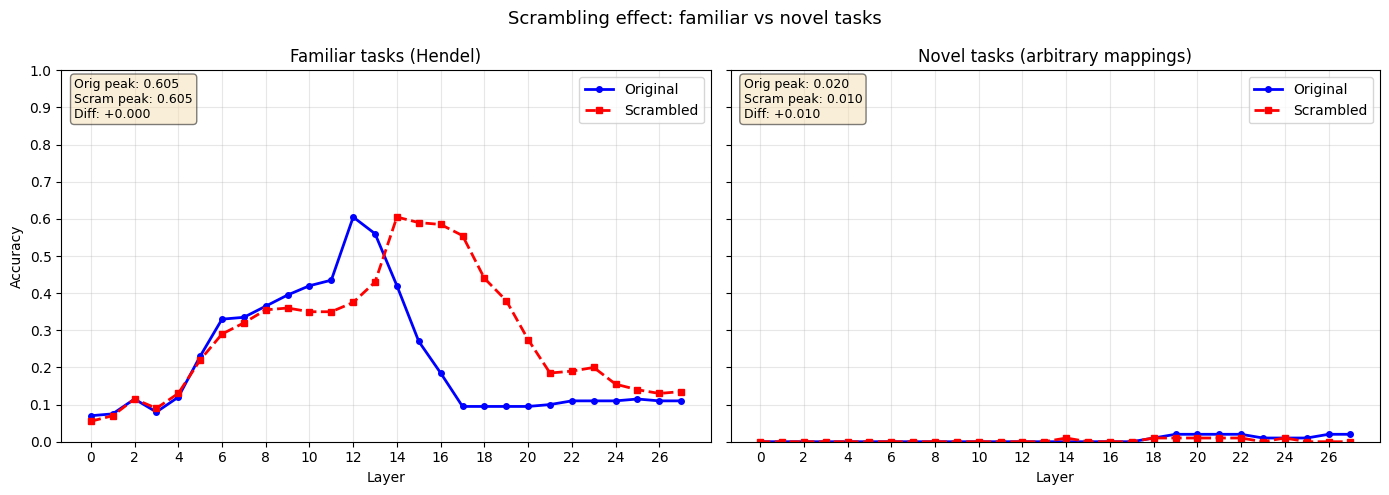

Familiar tasks:  orig=0.605, scram=0.605, diff=+0.000
Novel tasks:     orig=0.020, scram=0.010, diff=+0.010


In [39]:
layers = list(range(n_layers))
 
novel_orig_curve = [np.mean(novel_orig_accs[l]) for l in layers]
novel_scram_curve = [np.mean(novel_scram_accs[l]) for l in layers]
 
# Reuse Hendel curves from the earlier experiment
hendel_orig_curve = [np.mean(orig_per_task[t][l] 
                     for t in orig_per_task for _ in [None]) 
                     if False else 0 for l in layers]
# Simpler: just recompute from orig_per_task
hendel_orig_curve = []
hendel_scram_curve = []
for l in layers:
    o_vals, s_vals = [], []
    for t in orig_per_task:
        o_vals.extend(orig_per_task[t][l])
        s_vals.extend(scram_per_task[t][l])
    hendel_orig_curve.append(np.mean(o_vals) if o_vals else 0)
    hendel_scram_curve.append(np.mean(s_vals) if s_vals else 0)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
# Hendel (familiar) tasks
ax = axes[0]
ax.plot(layers, hendel_orig_curve, 'b-o', ms=4, lw=2, label='Original')
ax.plot(layers, hendel_scram_curve, 'r--s', ms=4, lw=2, label='Scrambled')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Familiar tasks (Hendel)')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
peak_ho = max(hendel_orig_curve)
peak_hs = max(hendel_scram_curve)
ax.text(0.02, 0.98, f'Orig peak: {peak_ho:.3f}\nScram peak: {peak_hs:.3f}\nDiff: {peak_ho - peak_hs:+.3f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
# Novel (synthetic) tasks
ax = axes[1]
ax.plot(layers, novel_orig_curve, 'b-o', ms=4, lw=2, label='Original')
ax.plot(layers, novel_scram_curve, 'r--s', ms=4, lw=2, label='Scrambled')
ax.set_xlabel('Layer')
ax.set_title('Novel tasks (arbitrary mappings)')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
peak_no = max(novel_orig_curve)
peak_ns = max(novel_scram_curve)
ax.text(0.02, 0.98, f'Orig peak: {peak_no:.3f}\nScram peak: {peak_ns:.3f}\nDiff: {peak_no - peak_ns:+.3f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
fig.suptitle('Scrambling effect: familiar vs novel tasks', fontsize=13)
plt.tight_layout()
plt.show()
 
print(f'Familiar tasks:  orig={peak_ho:.3f}, scram={peak_hs:.3f}, diff={peak_ho-peak_hs:+.3f}')
print(f'Novel tasks:     orig={peak_no:.3f}, scram={peak_ns:.3f}, diff={peak_no-peak_ns:+.3f}')

In [40]:
print(f'{"Task":<20s}  {"Orig peak":>10s}  {"Scram peak":>11s}  {"Diff":>6s}  {"Example pairs"}')
print('-' * 85)
for t in sorted(synthetic_tasks.keys()):
    orig_c = [np.mean(novel_orig_per_task[t][l]) for l in layers]
    scram_c = [np.mean(novel_scram_per_task[t][l]) for l in layers]
    po, ps = max(orig_c), max(scram_c)
    pairs_str = ', '.join(f'{i}→{o}' for i, o in synthetic_tasks[t]['all_pairs'][:3])
    print(f'{t:<20s}  {po:>10.3f}  {ps:>11.3f}  {po-ps:>+6.3f}  {pairs_str}...')

Task                   Orig peak   Scram peak    Diff  Example pairs
-------------------------------------------------------------------------------------
synthetic_0                0.000        0.000  +0.000  table→rock, bee→drop, tree→swim...
synthetic_1                0.000        0.000  +0.000  pair→table, milk→owl, jam→rice...
synthetic_2                0.000        0.000  +0.000  deer→seed, drum→eye, pig→ale...
synthetic_3                0.000        0.000  +0.000  ear→mud, blue→frog, lamp→bread...
synthetic_4                0.000        0.000  +0.000  rage→tea, fog→cup, turn→hill...
synthetic_5                0.100        0.000  +0.100  corn→lip, jump→sky, ant→swim...
synthetic_6                0.100        0.100  +0.000  wine→tea, ant→cake, foot→corn...
synthetic_7                0.000        0.000  +0.000  ram→ring, jaw→pull, green→ice...
synthetic_8                0.000        0.000  +0.000  wolf→pen, salt→cat, fear→flag...
synthetic_9                0.100        0.100  +0.00

In [41]:
# For each demo's output position at each layer, apply logit lens (W_U @ h)
# and track the rank of: (a) the output word itself, (b) the paired input word,
# (c) other output words in the prompt, (d) other input words.
 
W_U = model.W_U.detach().cpu().float()  # [d_model, vocab]
# Note: in TransformerLens, W_U is [d_model, vocab], so logits = h @ W_U
 
N_PROMPTS = 5  # per task (logit lens is cheap, but we want many demos)
RESID_FILTER = lambda name: 'resid_post' in name
 
# Track per-layer: rank of output word, rank of paired input, logit of output, logit of input
output_word_ranks = defaultdict(list)   # layer -> [ranks]
paired_input_ranks = defaultdict(list)  # layer -> [ranks]
output_word_logits = defaultdict(list)
paired_input_logits = defaultdict(list)
# Also: does the output position decode as another demo's output?
other_output_ranks = defaultdict(list)  # layer -> [min rank of any OTHER output word]
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        demos = pdata['demo_pairs']
        prompt = pdata['prompt']
        
        tokens = model.to_tokens(prompt, prepend_bos=True)
        per_demo = find_per_demo_positions(model, prompt, demos)
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        for demo_idx, demo_info in enumerate(per_demo):
            out_positions = demo_info['output_positions']
            if not out_positions:
                continue
            
            out_pos = out_positions[0]  # first output token position
            inp_word = demos[demo_idx][0]
            out_word = demos[demo_idx][1]
            
            # Get token IDs for input and output words
            inp_tok = model.to_tokens(inp_word, prepend_bos=False)[0][0].item()
            out_tok = model.to_tokens(out_word, prepend_bos=False)[0][0].item()
            
            # Other output words in this prompt
            other_out_toks = []
            for j, (_, o) in enumerate(demos):
                if j != demo_idx:
                    t = model.to_tokens(o, prepend_bos=False)[0][0].item()
                    other_out_toks.append(t)
            
            for layer in range(n_layers):
                h = cache['resid_post', layer][0, out_pos].cpu().float()
                
                # Apply layer norm if model uses it (Llama does)
                if hasattr(model, 'ln_final'):
                    h_normed = model.ln_final(h.unsqueeze(0).to(model.cfg.device)).cpu().float().squeeze(0)
                else:
                    h_normed = h
                
                logits = h_normed @ W_U  # [vocab]
                
                # Ranks (lower = more prominent)
                sorted_indices = torch.argsort(logits, descending=True)
                ranks = torch.zeros(logits.shape[0], dtype=torch.long)
                ranks[sorted_indices] = torch.arange(len(sorted_indices))
                
                output_word_ranks[layer].append(ranks[out_tok].item())
                paired_input_ranks[layer].append(ranks[inp_tok].item())
                output_word_logits[layer].append(logits[out_tok].item())
                paired_input_logits[layer].append(logits[inp_tok].item())
                
                if other_out_toks:
                    other_ranks = [ranks[t].item() for t in other_out_toks]
                    other_output_ranks[layer].append(min(other_ranks))
        
        del cache
        torch.cuda.empty_cache()
 
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Logit lens extraction complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Logit lens extraction complete.


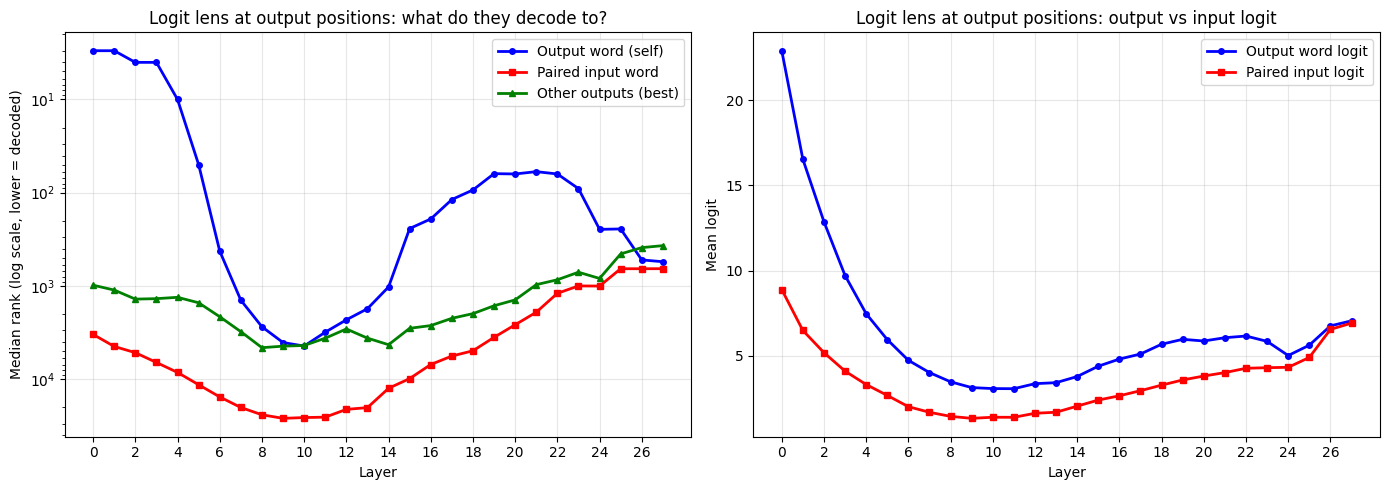

Layer  0: output rank=     3, input rank=  3318, other-output rank=   983
Layer  4: output rank=    10, input rank=  8482, other-output rank=  1326
Layer  8: output rank=  2744, input rank= 24140, other-output rank=  4601
Layer 12: output rank=  2313, input rank= 21125, other-output rank=  2898
Layer 16: output rank=   192, input rank=  6974, other-output rank=  2666
Layer 20: output rank=    63, input rank=  2612, other-output rank=  1412
Layer 24: output rank=   248, input rank=  1004, other-output rank=   832
Layer 27: output rank=   550, input rank=   654, other-output rank=   370


In [42]:
layers = list(range(n_layers))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: median rank (log scale) of output word vs paired input at output position
ax = axes[0]
out_med = [np.median(output_word_ranks[l]) for l in layers]
inp_med = [np.median(paired_input_ranks[l]) for l in layers]
other_med = [np.median(other_output_ranks[l]) for l in layers]
 
ax.semilogy(layers, out_med, 'b-o', ms=4, lw=2, label='Output word (self)')
ax.semilogy(layers, inp_med, 'r-s', ms=4, lw=2, label='Paired input word')
ax.semilogy(layers, other_med, 'g-^', ms=4, lw=2, label='Other outputs (best)')
ax.set_xlabel('Layer')
ax.set_ylabel('Median rank (log scale, lower = decoded)')
ax.set_title('Logit lens at output positions: what do they decode to?')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
ax.invert_yaxis()  # lower rank = better, put at top
 
# Right: mean logit
ax = axes[1]
out_logit = [np.mean(output_word_logits[l]) for l in layers]
inp_logit = [np.mean(paired_input_logits[l]) for l in layers]
 
ax.plot(layers, out_logit, 'b-o', ms=4, lw=2, label='Output word logit')
ax.plot(layers, inp_logit, 'r-s', ms=4, lw=2, label='Paired input logit')
ax.set_xlabel('Layer')
ax.set_ylabel('Mean logit')
ax.set_title('Logit lens at output positions: output vs input logit')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
 
plt.tight_layout()
plt.show()
 
# Print key layers
for l in [0, 4, 8, 12, 16, 20, 24, 27]:
    print(f'Layer {l:2d}: output rank={np.median(output_word_ranks[l]):6.0f}, '
          f'input rank={np.median(paired_input_ranks[l]):6.0f}, '
          f'other-output rank={np.median(other_output_ranks[l]):6.0f}')
 

In [43]:
# For each task, collect hidden states at output positions and try to
# predict which INPUT word was paired with this output.
# If we can → Cho's merge happened, input info is present.
# If we can't → output positions are pure output identity.
#
# Method: for each task, for each layer, fit a simple linear probe
# (or just measure cosine separability) to classify input identity
# from output-position hidden states.
#
# Simpler approach: compute the cosine similarity between the output
# position's hidden state and the input word's embedding vs the output
# word's embedding. Which is higher? How does this change across layers?
 
# Collect (h_at_output_pos, input_embedding_cos, output_embedding_cos) per layer
input_cos_at_outpos = defaultdict(list)   # layer -> cosines with input embedding
output_cos_at_outpos = defaultdict(list)  # layer -> cosines with output embedding
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        demos = pdata['demo_pairs']
        prompt = pdata['prompt']
        
        tokens = model.to_tokens(prompt, prepend_bos=True)
        per_demo = find_per_demo_positions(model, prompt, demos)
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        for demo_idx, demo_info in enumerate(per_demo):
            out_positions = demo_info['output_positions']
            if not out_positions:
                continue
            
            out_pos = out_positions[0]
            inp_word = demos[demo_idx][0]
            out_word = demos[demo_idx][1]
            
            inp_tok = model.to_tokens(inp_word, prepend_bos=False)[0][0].item()
            out_tok = model.to_tokens(out_word, prepend_bos=False)[0][0].item()
            
            e_inp = W_E[inp_tok].numpy()
            e_out = W_E[out_tok].numpy()
            
            for layer in range(n_layers):
                h = cache['resid_post', layer][0, out_pos].cpu().float().numpy()
                
                cos_inp = np.dot(h, e_inp) / (np.linalg.norm(h) * np.linalg.norm(e_inp) + 1e-10)
                cos_out = np.dot(h, e_out) / (np.linalg.norm(h) * np.linalg.norm(e_out) + 1e-10)
                
                input_cos_at_outpos[layer].append(cos_inp)
                output_cos_at_outpos[layer].append(cos_out)
        
        del cache
        torch.cuda.empty_cache()
 
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Embedding cosine extraction complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Embedding cosine extraction complete.


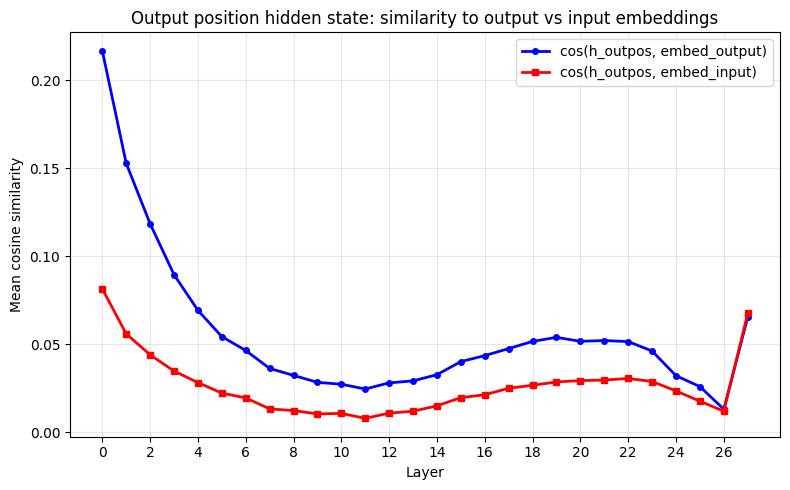

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
 
inp_means = [np.mean(input_cos_at_outpos[l]) for l in layers]
out_means = [np.mean(output_cos_at_outpos[l]) for l in layers]
 
ax.plot(layers, out_means, 'b-o', ms=4, lw=2, label='cos(h_outpos, embed_output)')
ax.plot(layers, inp_means, 'r-s', ms=4, lw=2, label='cos(h_outpos, embed_input)')
ax.set_xlabel('Layer')
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Output position hidden state: similarity to output vs input embeddings')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
plt.tight_layout()
plt.show()

In [45]:
# Do output positions THEMSELVES change when pairings are scrambled?
# If yes: they contain pairing info, and the pairing-invariance of the TV
#         must come from the readout mechanism (IH OV or downstream).
# If no:  output positions don't encode their paired input, so the TV
#         is pairing-invariant because its source is pairing-invariant.
#
# Method: for each prompt, build original and scrambled versions.
# At each output position, compute cosine between original and scrambled
# hidden states at that position.
 
orig_vs_scram_at_outpos = defaultdict(list)  # layer -> cosines
# Also track: does the scrambled output position still decode as the same word?
# (It should — the output TOKEN is the same, just the preceding input changed)
scram_output_rank = defaultdict(list)
 
N_PROMPTS_COMP = 5
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        # Original
        prompt_orig = pdata['prompt']
        
        # Scrambled
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        per_demo_scram = find_per_demo_positions(model, prompt_scrambled, demos_scrambled)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        for demo_idx in range(len(demos)):
            out_pos_orig = per_demo_orig[demo_idx]['output_positions']
            out_pos_scram = per_demo_scram[demo_idx]['output_positions']
            
            if not out_pos_orig or not out_pos_scram:
                continue
            
            for layer in range(n_layers):
                h_orig = cache_orig['resid_post', layer][0, out_pos_orig[0]].cpu().float().numpy()
                h_scram = cache_scram['resid_post', layer][0, out_pos_scram[0]].cpu().float().numpy()
                
                cos = np.dot(h_orig, h_scram) / (np.linalg.norm(h_orig) * np.linalg.norm(h_scram) + 1e-10)
                orig_vs_scram_at_outpos[layer].append(cos)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
 
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Original vs scrambled comparison complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Original vs scrambled comparison complete.


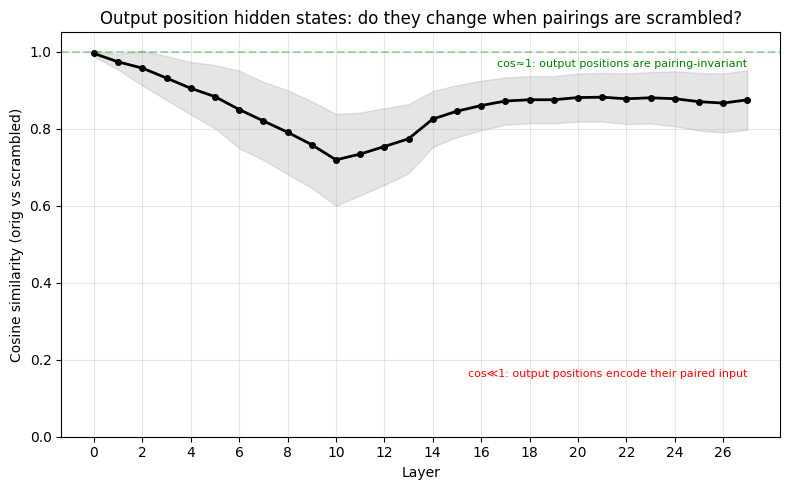


Cosine (orig vs scram) at output positions:
  Layer  0: 0.9952 ± 0.0075
  Layer  4: 0.9047 ± 0.0682
  Layer  8: 0.7906 ± 0.1091
  Layer 12: 0.7535 ± 0.0998
  Layer 16: 0.8599 ± 0.0644
  Layer 20: 0.8806 ± 0.0623
  Layer 24: 0.8776 ± 0.0713
  Layer 27: 0.8747 ± 0.0778


In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
 
cos_curve = [np.mean(orig_vs_scram_at_outpos[l]) for l in layers]
cos_std = [np.std(orig_vs_scram_at_outpos[l]) for l in layers]
 
ax.plot(layers, cos_curve, 'k-o', ms=4, lw=2)
ax.fill_between(layers, 
                [m - s for m, s in zip(cos_curve, cos_std)],
                [m + s for m, s in zip(cos_curve, cos_std)],
                alpha=0.2, color='gray')
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Output position hidden states: do they change when pairings are scrambled?')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
 
# Annotate interpretation
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.text(n_layers - 1, 0.98, 'cos≈1: output positions are pairing-invariant', 
        ha='right', va='top', fontsize=8, color='green')
ax.text(n_layers - 1, 0.15, 'cos≪1: output positions encode their paired input', 
        ha='right', va='bottom', fontsize=8, color='red')
 
plt.tight_layout()
plt.show()
 
# Print values at key layers
print(f'\nCosine (orig vs scram) at output positions:')
for l in [0, 4, 8, 12, 16, 20, 24, 27]:
    print(f'  Layer {l:2d}: {np.mean(orig_vs_scram_at_outpos[l]):.4f} ± {np.std(orig_vs_scram_at_outpos[l]):.4f}')

In [47]:
from numpy.linalg import qr
 
W_U_np = W_U.numpy()  # [d_model, vocab]
 
N_PROMPTS_COMP = 5
RESID_FILTER = lambda name: 'resid_post' in name
 
# Store cosines: full space vs task-subspace vs orthogonal complement
cos_full = defaultdict(list)         # layer -> cosines (should match Analysis 3)
cos_task_subspace = defaultdict(list) # layer -> cosines in task subspace
cos_orthogonal = defaultdict(list)    # layer -> cosines in orthogonal complement
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    # Build task subspace from unique output words' unembeddings
    all_out_words = list(set(out for _, out in tasks[task_name]))
    out_tok_ids = []
    for w in all_out_words:
        tok = model.to_tokens(w, prepend_bos=False)[0][0].item()
        out_tok_ids.append(tok)
    
    # Unembedding vectors for this task's outputs: [n_outputs, d_model]
    U_task = W_U_np[:, out_tok_ids].T  # [n_outputs, d_model]
    
    # Orthonormalize to get task subspace basis: [rank, d_model]
    Q, _ = qr(U_task.T, mode='reduced')  # Q: [d_model, rank]
    Q_task = Q  # columns are orthonormal basis vectors of task subspace
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        per_demo_scram = find_per_demo_positions(model, prompt_scrambled, demos_scrambled)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        for demo_idx in range(len(demos)):
            out_pos_orig = per_demo_orig[demo_idx]['output_positions']
            out_pos_scram = per_demo_scram[demo_idx]['output_positions']
            
            if not out_pos_orig or not out_pos_scram:
                continue
            
            for layer in range(n_layers):
                h_orig = cache_orig['resid_post', layer][0, out_pos_orig[0]].cpu().float().numpy()
                h_scram = cache_scram['resid_post', layer][0, out_pos_scram[0]].cpu().float().numpy()
                
                # Full-space cosine (sanity check — should match Analysis 3)
                cos_f = np.dot(h_orig, h_scram) / (np.linalg.norm(h_orig) * np.linalg.norm(h_scram) + 1e-10)
                cos_full[layer].append(cos_f)
                
                # Project onto task subspace: h_proj = Q @ Q^T @ h
                h_orig_task = Q_task @ (Q_task.T @ h_orig)
                h_scram_task = Q_task @ (Q_task.T @ h_scram)
                
                n_orig_t = np.linalg.norm(h_orig_task)
                n_scram_t = np.linalg.norm(h_scram_task)
                if n_orig_t > 1e-10 and n_scram_t > 1e-10:
                    cos_t = np.dot(h_orig_task, h_scram_task) / (n_orig_t * n_scram_t)
                    cos_task_subspace[layer].append(cos_t)
                
                # Project onto orthogonal complement: h_orth = h - h_proj
                h_orig_orth = h_orig - h_orig_task
                h_scram_orth = h_scram - h_scram_task
                
                n_orig_o = np.linalg.norm(h_orig_orth)
                n_scram_o = np.linalg.norm(h_scram_orth)
                if n_orig_o > 1e-10 and n_scram_o > 1e-10:
                    cos_o = np.dot(h_orig_orth, h_scram_orth) / (n_orig_o * n_scram_o)
                    cos_orthogonal[layer].append(cos_o)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
    
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Subspace projection complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Subspace projection complete.


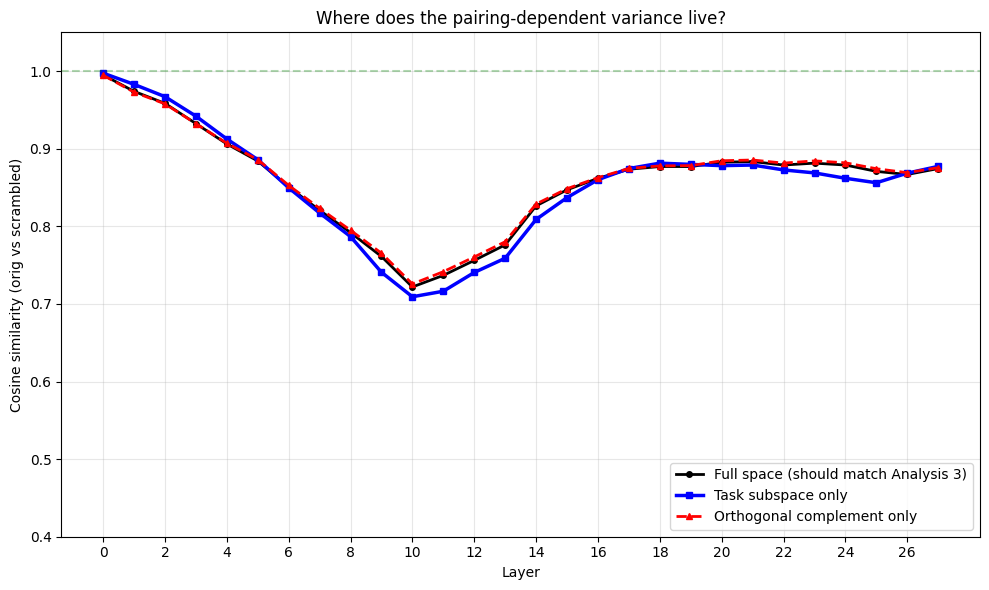


Layer    Full    Task    Orth
------------------------------
    0   0.995   0.997   0.995
    4   0.906   0.913   0.907
    8   0.792   0.787   0.795
   12   0.756   0.741   0.761
   14   0.826   0.809   0.829
   16   0.862   0.860   0.863
   20   0.883   0.878   0.885
   24   0.879   0.862   0.882
   27   0.874   0.877   0.876


In [48]:
layers = list(range(n_layers))
 
fig, ax = plt.subplots(figsize=(10, 6))
 
full_curve = [np.mean(cos_full[l]) for l in layers]
task_curve = [np.mean(cos_task_subspace[l]) for l in layers]
orth_curve = [np.mean(cos_orthogonal[l]) for l in layers]
 
ax.plot(layers, full_curve, 'k-o', ms=4, lw=2, label='Full space (should match Analysis 3)')
ax.plot(layers, task_curve, 'b-s', ms=5, lw=2.5, label='Task subspace only')
ax.plot(layers, orth_curve, 'r--^', ms=4, lw=2, label='Orthogonal complement only')
 
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Where does the pairing-dependent variance live?')
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
 
print(f'\n{"Layer":>5s}  {"Full":>6s}  {"Task":>6s}  {"Orth":>6s}')
print('-' * 30)
for l in [0, 4, 8, 12, 14, 16, 20, 24, 27]:
    print(f'{l:5d}  {np.mean(cos_full[l]):6.3f}  {np.mean(cos_task_subspace[l]):6.3f}  {np.mean(cos_orthogonal[l]):6.3f}')

In [49]:
# Also useful: what fraction of the hidden state's norm lives in the task
# subspace vs the orthogonal complement? If 99% is orthogonal, then even
# large pairing effects in the orthogonal complement barely matter.
 
frac_task = defaultdict(list)      # layer -> fraction of norm in task subspace
frac_orth = defaultdict(list)
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    all_out_words = list(set(out for _, out in tasks[task_name]))
    out_tok_ids = []
    for w in all_out_words:
        tok = model.to_tokens(w, prepend_bos=False)[0][0].item()
        out_tok_ids.append(tok)
    
    U_task = W_U_np[:, out_tok_ids].T
    Q, _ = qr(U_task.T, mode='reduced')
    Q_task = Q
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        per_demo = find_per_demo_positions(model, prompt, demos)
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        for demo_idx, demo_info in enumerate(per_demo):
            out_positions = demo_info['output_positions']
            if not out_positions:
                continue
            
            for layer in range(n_layers):
                h = cache['resid_post', layer][0, out_positions[0]].cpu().float().numpy()
                h_task = Q_task @ (Q_task.T @ h)
                
                norm_total = np.linalg.norm(h) ** 2
                norm_task = np.linalg.norm(h_task) ** 2
                
                if norm_total > 1e-10:
                    frac_task[layer].append(norm_task / norm_total)
                    frac_orth[layer].append(1 - norm_task / norm_total)
        
        del cache
        torch.cuda.empty_cache()
 
fig, ax = plt.subplots(figsize=(8, 5))
task_frac_curve = [np.mean(frac_task[l]) * 100 for l in layers]
ax.plot(layers, task_frac_curve, 'b-o', ms=4, lw=2)
ax.set_xlabel('Layer')
ax.set_ylabel('% of hidden state norm in task subspace')
ax.set_title('How much of the output position lives in the task subspace?')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, n_layers, 2))
plt.tight_layout()
plt.show()
 
for l in [0, 4, 8, 12, 16, 20, 24, 27]:
    print(f'Layer {l:2d}: {np.mean(frac_task[l])*100:5.2f}% in task subspace')

KeyboardInterrupt: 

In [50]:
N_PROMPTS_COMP = 5
RESID_FILTER = lambda name: 'resid_post' in name
 
cos_per_position = defaultdict(list)   # layer -> cosines (individual, same as Analysis 3)
cos_aggregated = defaultdict(list)     # layer -> cosines (mean across output positions)
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        per_demo_scram = find_per_demo_positions(model, prompt_scrambled, demos_scrambled)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        for layer in range(n_layers):
            # Collect all output-position hidden states for this prompt
            vecs_orig = []
            vecs_scram = []
            
            for demo_idx in range(len(demos)):
                out_pos_orig = per_demo_orig[demo_idx]['output_positions']
                out_pos_scram = per_demo_scram[demo_idx]['output_positions']
                
                if not out_pos_orig or not out_pos_scram:
                    continue
                
                h_orig = cache_orig['resid_post', layer][0, out_pos_orig[0]].cpu().float().numpy()
                h_scram = cache_scram['resid_post', layer][0, out_pos_scram[0]].cpu().float().numpy()
                
                vecs_orig.append(h_orig)
                vecs_scram.append(h_scram)
                
                # Per-position cosine
                cos_pp = np.dot(h_orig, h_scram) / (np.linalg.norm(h_orig) * np.linalg.norm(h_scram) + 1e-10)
                cos_per_position[layer].append(cos_pp)
            
            if len(vecs_orig) >= 2:
                # Aggregated: mean across output positions
                mean_orig = np.mean(vecs_orig, axis=0)
                mean_scram = np.mean(vecs_scram, axis=0)
                
                cos_agg = np.dot(mean_orig, mean_scram) / (np.linalg.norm(mean_orig) * np.linalg.norm(mean_scram) + 1e-10)
                cos_aggregated[layer].append(cos_agg)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
    
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Aggregation test complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Aggregation test complete.


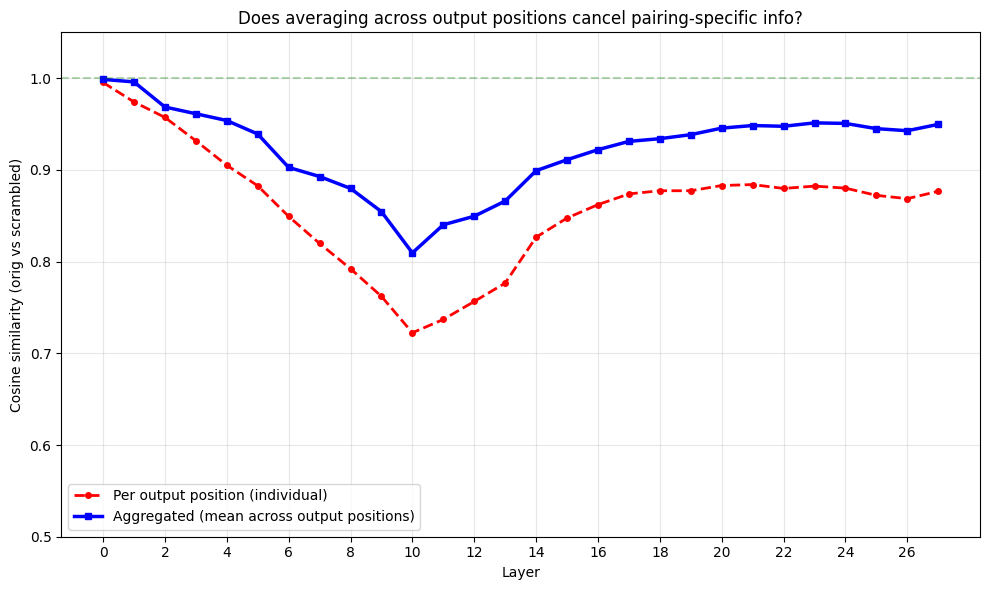


Layer   Per-pos   Aggregated    Gain
-----------------------------------
    0    0.9953       0.9987  +0.0034
    4    0.9051       0.9538  +0.0488
    8    0.7922       0.8798  +0.0876
   10    0.7224       0.8095  +0.0871
   12    0.7565       0.8495  +0.0929
   14    0.8266       0.8991  +0.0725
   16    0.8621       0.9220  +0.0599
   20    0.8830       0.9455  +0.0626
   24    0.8801       0.9507  +0.0706
   27    0.8767       0.9497  +0.0730


In [51]:
layers = list(range(n_layers))
 
fig, ax = plt.subplots(figsize=(10, 6))
 
pp_curve = [np.mean(cos_per_position[l]) for l in layers]
agg_curve = [np.mean(cos_aggregated[l]) for l in layers]
 
ax.plot(layers, pp_curve, 'r--o', ms=4, lw=2, label='Per output position (individual)')
ax.plot(layers, agg_curve, 'b-s', ms=5, lw=2.5, label='Aggregated (mean across output positions)')
 
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Does averaging across output positions cancel pairing-specific info?')
ax.set_ylim(0.5, 1.05)
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
 
print(f'\n{"Layer":>5s}  {"Per-pos":>8s}  {"Aggregated":>11s}  {"Gain":>6s}')
print('-' * 35)
for l in [0, 4, 8, 10, 12, 14, 16, 20, 24, 27]:
    pp = np.mean(cos_per_position[l])
    ag = np.mean(cos_aggregated[l])
    print(f'{l:5d}  {pp:8.4f}  {ag:11.4f}  {ag - pp:+6.4f}')

In [52]:
HEAD_Z_FILTER = lambda name: 'hook_z' in name or 'attn.hook_pattern' in name
RESID_FILTER = lambda name: 'resid_post' in name
 
N_PROMPTS_COMP = 5
 
# Per head: cosine between orig and scrambled IH output at final position
ih_output_cos = defaultdict(lambda: defaultdict(list))  # (layer, head) -> [cosines]
# Aggregated across all output-attending heads at each layer
ih_agg_cos_per_layer = defaultdict(list)  # layer -> [cosines]
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        per_demo_scram = find_per_demo_positions(model, prompt_scrambled, demos_scrambled)
        
        # Get output token positions
        out_positions_orig = []
        out_positions_scram = []
        for demo_idx in range(len(demos)):
            op_o = per_demo_orig[demo_idx]['output_positions']
            op_s = per_demo_scram[demo_idx]['output_positions']
            if op_o:
                out_positions_orig.append(op_o[0])
            if op_s:
                out_positions_scram.append(op_s[0])
        
        last_pos_orig = tokens_orig.shape[1] - 1
        last_pos_scram = tokens_scram.shape[1] - 1
        
        # Cache: need attention patterns + residual stream (for OV input)
        names_orig = lambda name: 'hook_z' in name or 'attn.hook_pattern' in name
        names_scram = lambda name: 'hook_z' in name or 'attn.hook_pattern' in name
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=names_orig)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=names_scram)
        
        for l, h in output_attending_heads:
            # Attention pattern from final position to all positions
            # hook_pattern shape: [batch, n_heads, seq_len, seq_len]
            attn_orig = cache_orig[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos_orig, :].cpu().float()
            attn_scram = cache_scram[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos_scram, :].cpu().float()
            
            # hook_z is the post-attention, pre-W_O value: [batch, seq_len, n_heads, d_head]
            # The actual head output at the final position is already computed as:
            # out = sum_i attn[i] * (h_i @ W_V) @ W_O
            # which equals hook_z[final_pos, head] @ W_O
            # So hook_z already has the attention-weighted sum built in.
            
            z_orig = cache_orig[f'blocks.{l}.attn.hook_z'][0, last_pos_orig, h].cpu().float().numpy()
            z_scram = cache_scram[f'blocks.{l}.attn.hook_z'][0, last_pos_scram, h].cpu().float().numpy()
            
            # Apply W_O to get the actual head output in residual stream space
            W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()  # [d_head, d_model]
            
            head_out_orig = z_orig @ W_O  # [d_model]
            head_out_scram = z_scram @ W_O  # [d_model]
            
            cos = np.dot(head_out_orig, head_out_scram) / (
                np.linalg.norm(head_out_orig) * np.linalg.norm(head_out_scram) + 1e-10)
            ih_output_cos[(l, h)][task_name].append(cos)
        
        # Also compute the SUM of all IH outputs at each layer
        for l in set(l for l, h in output_attending_heads):
            heads_at_l = [h for ll, h in output_attending_heads if ll == l]
            
            sum_orig = np.zeros(d_model)
            sum_scram = np.zeros(d_model)
            for h in heads_at_l:
                z_o = cache_orig[f'blocks.{l}.attn.hook_z'][0, last_pos_orig, h].cpu().float().numpy()
                z_s = cache_scram[f'blocks.{l}.attn.hook_z'][0, last_pos_scram, h].cpu().float().numpy()
                W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
                sum_orig += z_o @ W_O
                sum_scram += z_s @ W_O
            
            cos_sum = np.dot(sum_orig, sum_scram) / (
                np.linalg.norm(sum_orig) * np.linalg.norm(sum_scram) + 1e-10)
            ih_agg_cos_per_layer[l].append(cos_sum)
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
    
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('IH output extraction complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
IH output extraction complete.


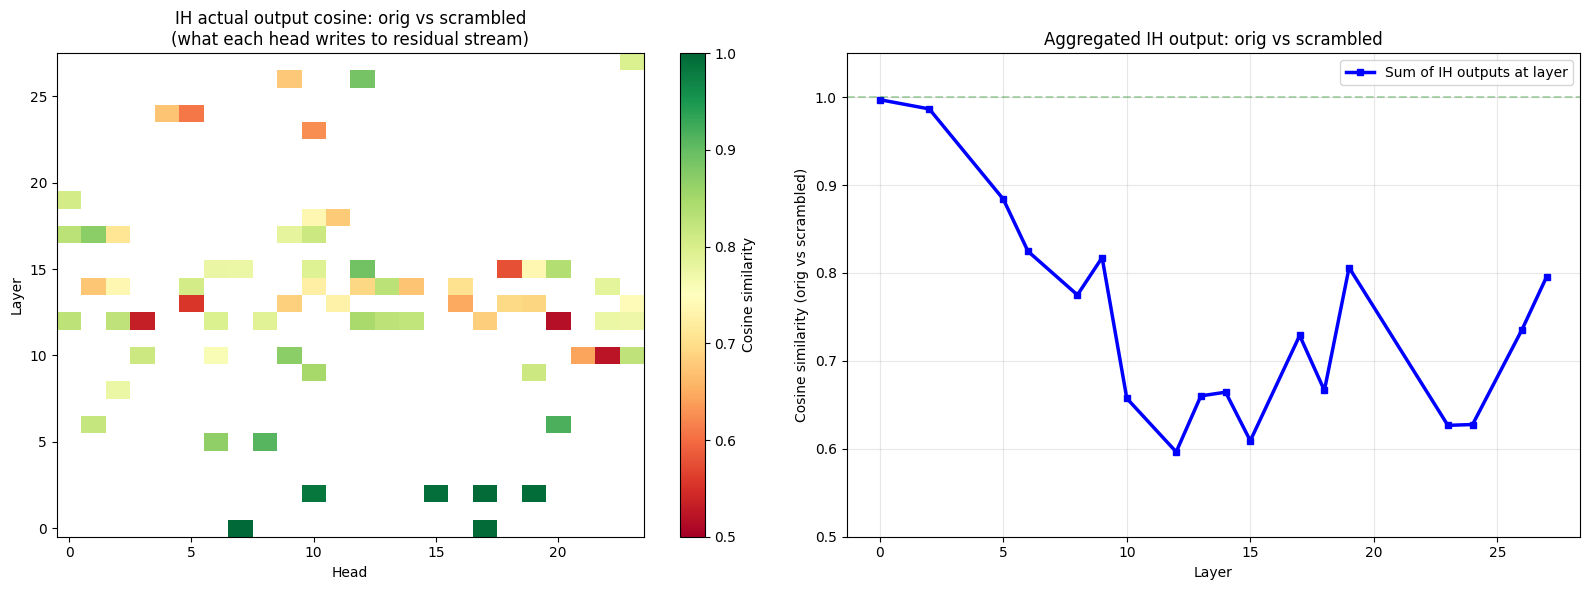


Layer  IH agg cos  n_heads
----------------------------
    0      0.9970        2
    2      0.9865        4
    5      0.8839        2
    6      0.8246        2
    8      0.7750        1
    9      0.8175        2
   10      0.6573        6
   12      0.5965       12
   13      0.6602        7
   14      0.6644        9
   15      0.6091        7
   17      0.7289        5
   18      0.6664        2
   19      0.8061        1
   23      0.6267        1
   24      0.6276        2
   26      0.7354        2
   27      0.7958        1


In [53]:
# Per-head mean cosine
head_cos_means = {}
for (l, h), task_dict in ih_output_cos.items():
    all_vals = [v for vals in task_dict.values() for v in vals]
    head_cos_means[(l, h)] = np.mean(all_vals)
 
# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Left: per-head heatmap (same format as your Image 3)
ax = axes[0]
heatmap = np.full((n_layers, n_heads), np.nan)
for (l, h), mean_cos in head_cos_means.items():
    heatmap[l, h] = mean_cos
 
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
cmap.set_bad('white')
im = ax.imshow(heatmap, aspect='auto', origin='lower', cmap=cmap, vmin=0.5, vmax=1.0)
ax.set_xlabel('Head')
ax.set_ylabel('Layer')
ax.set_title('IH actual output cosine: orig vs scrambled\n(what each head writes to residual stream)')
plt.colorbar(im, ax=ax, label='Cosine similarity')
 
# Right: aggregated IH output per layer
ax = axes[1]
ih_layers = sorted(ih_agg_cos_per_layer.keys())
agg_curve = [np.mean(ih_agg_cos_per_layer[l]) for l in ih_layers]
ax.plot(ih_layers, agg_curve, 'b-s', ms=5, lw=2.5, label='Sum of IH outputs at layer')
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Aggregated IH output: orig vs scrambled')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
 
plt.tight_layout()
plt.show()
 
# Print per-layer aggregated
print(f'\n{"Layer":>5s}  {"IH agg cos":>10s}  {"n_heads":>7s}')
print('-' * 28)
for l in ih_layers:
    n_h = len([h for ll, h in output_attending_heads if ll == l])
    print(f'{l:5d}  {np.mean(ih_agg_cos_per_layer[l]):10.4f}  {n_h:7d}')

In [54]:
COMPONENT_FILTER = lambda name: (
    'hook_attn_out' in name or    # attention output (sum across heads) at this layer
    'hook_mlp_out' in name or     # MLP output at this layer
    'resid_pre' in name           # residual stream input to this layer
)
 
N_PROMPTS_COMP = 5
 
# Cosines for each component type
cos_attn_out = defaultdict(list)      # layer -> cosines for attention output
cos_mlp_out = defaultdict(list)       # layer -> cosines for MLP output
cos_resid_pre = defaultdict(list)     # layer -> cosines for residual stream input
cos_resid_post_attn = defaultdict(list)  # layer -> cosines for resid_pre + attn_out
cos_resid_post_mlp = defaultdict(list)   # layer -> cosines for resid_pre + attn_out + mlp_out
 
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        per_demo_scram = find_per_demo_positions(model, prompt_scrambled, demos_scrambled)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=COMPONENT_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=COMPONENT_FILTER)
        
        for demo_idx in range(len(demos)):
            out_pos_orig = per_demo_orig[demo_idx]['output_positions']
            out_pos_scram = per_demo_scram[demo_idx]['output_positions']
            
            if not out_pos_orig or not out_pos_scram:
                continue
            
            pos_o = out_pos_orig[0]
            pos_s = out_pos_scram[0]
            
            for layer in range(n_layers):
                # Attention output (the additive contribution from attention at this layer)
                attn_o = cache_orig[f'blocks.{layer}.hook_attn_out'][0, pos_o].cpu().float().numpy()
                attn_s = cache_scram[f'blocks.{layer}.hook_attn_out'][0, pos_s].cpu().float().numpy()
                
                # MLP output (the additive contribution from MLP at this layer)
                mlp_o = cache_orig[f'blocks.{layer}.hook_mlp_out'][0, pos_o].cpu().float().numpy()
                mlp_s = cache_scram[f'blocks.{layer}.hook_mlp_out'][0, pos_s].cpu().float().numpy()
                
                # Residual stream input to this layer
                resid_o = cache_orig[f'blocks.{layer}.hook_resid_pre'][0, pos_o].cpu().float().numpy()
                resid_s = cache_scram[f'blocks.{layer}.hook_resid_pre'][0, pos_s].cpu().float().numpy()
                
                def safe_cos(a, b):
                    na, nb = np.linalg.norm(a), np.linalg.norm(b)
                    if na > 1e-10 and nb > 1e-10:
                        return np.dot(a, b) / (na * nb)
                    return np.nan
                
                cos_attn_out[layer].append(safe_cos(attn_o, attn_s))
                cos_mlp_out[layer].append(safe_cos(mlp_o, mlp_s))
                cos_resid_pre[layer].append(safe_cos(resid_o, resid_s))
                
                # Cumulative: post-attention = resid_pre + attn_out
                post_attn_o = resid_o + attn_o
                post_attn_s = resid_s + attn_s
                cos_resid_post_attn[layer].append(safe_cos(post_attn_o, post_attn_s))
                
                # Cumulative: post-MLP = resid_pre + attn_out + mlp_out
                post_mlp_o = post_attn_o + mlp_o
                post_mlp_s = post_attn_s + mlp_s
                cos_resid_post_mlp[layer].append(safe_cos(post_mlp_o, post_mlp_s))
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
    
    if (t_idx + 1) % 5 == 0:
        print(f'[{t_idx+1}/{len(all_splits)}] done')
 
print('Component decomposition complete.')

[5/20] done
[10/20] done
[15/20] done
[20/20] done
Component decomposition complete.


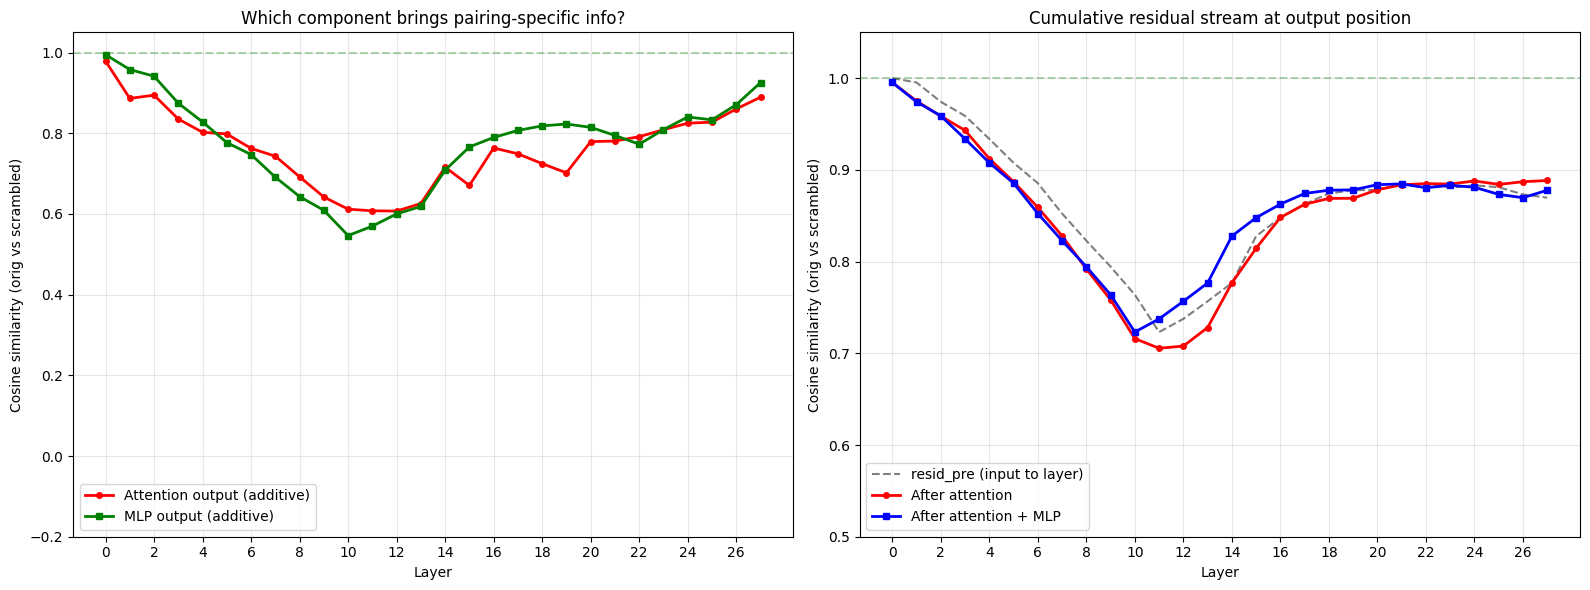


Layer    Attn     MLP     Pre   PostAttn   PostMLP
------------------------------------------------
    0   0.979   0.995   1.000      0.995     0.995
    2   0.894   0.941   0.974      0.959     0.959
    4   0.802   0.828   0.934      0.912     0.908
    6   0.762   0.747   0.886      0.859     0.852
    8   0.692   0.643   0.823      0.792     0.794
   10   0.612   0.546   0.764      0.716     0.723
   12   0.607   0.600   0.738      0.708     0.757
   14   0.716   0.708   0.777      0.777     0.828
   16   0.763   0.789   0.848      0.848     0.863
   20   0.779   0.815   0.878      0.878     0.884
   24   0.825   0.840   0.883      0.888     0.881
   27   0.889   0.925   0.870      0.888     0.878


In [55]:
layers = list(range(n_layers))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Left: additive components (what each component contributes)
ax = axes[0]
attn_curve = [np.nanmean(cos_attn_out[l]) for l in layers]
mlp_curve = [np.nanmean(cos_mlp_out[l]) for l in layers]
 
ax.plot(layers, attn_curve, 'r-o', ms=4, lw=2, label='Attention output (additive)')
ax.plot(layers, mlp_curve, 'g-s', ms=4, lw=2, label='MLP output (additive)')
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Which component brings pairing-specific info?')
ax.set_ylim(-0.2, 1.05)
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
 
# Right: cumulative residual stream
ax = axes[1]
pre_curve = [np.nanmean(cos_resid_pre[l]) for l in layers]
post_attn_curve = [np.nanmean(cos_resid_post_attn[l]) for l in layers]
post_mlp_curve = [np.nanmean(cos_resid_post_mlp[l]) for l in layers]
 
ax.plot(layers, pre_curve, 'k--', ms=3, lw=1.5, alpha=0.5, label='resid_pre (input to layer)')
ax.plot(layers, post_attn_curve, 'r-o', ms=4, lw=2, label='After attention')
ax.plot(layers, post_mlp_curve, 'b-s', ms=4, lw=2, label='After attention + MLP')
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig vs scrambled)')
ax.set_title('Cumulative residual stream at output position')
ax.set_ylim(0.5, 1.05)
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
 
plt.tight_layout()
plt.show()
 
# Print key layers
print(f'\n{"Layer":>5s}  {"Attn":>6s}  {"MLP":>6s}  {"Pre":>6s}  {"PostAttn":>9s}  {"PostMLP":>8s}')
print('-' * 48)
for l in [0, 2, 4, 6, 8, 10, 12, 14, 16, 20, 24, 27]:
    print(f'{l:5d}  {np.nanmean(cos_attn_out[l]):6.3f}  {np.nanmean(cos_mlp_out[l]):6.3f}  '
          f'{np.nanmean(cos_resid_pre[l]):6.3f}  {np.nanmean(cos_resid_post_attn[l]):9.3f}  '
          f'{np.nanmean(cos_resid_post_mlp[l]):8.3f}')

## Run here

In [57]:
from tqdm import tqdm

N_PROMPTS_COMP = 10
RESID_FILTER = lambda name: 'resid_post' in name

tv_cos = defaultdict(list)
tv_orig_correct = defaultdict(list)
tv_scram_correct = defaultdict(list)

total = len(all_splits) * N_PROMPTS_COMP
pbar = tqdm(total=total, desc='TV cosine')

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_COMP]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scrambled = build_icl_prompt(demos_scrambled, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scrambled, prepend_bos=True)
        
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
        
        last_orig = tokens_orig.shape[1] - 1
        last_scram = tokens_scram.shape[1] - 1
        
        for layer in range(n_layers):
            h_orig = cache_orig['resid_post', layer][0, last_orig].cpu().float().numpy()
            h_scram = cache_scram['resid_post', layer][0, last_scram].cpu().float().numpy()
            
            cos = np.dot(h_orig, h_scram) / (np.linalg.norm(h_orig) * np.linalg.norm(h_scram) + 1e-10)
            tv_cos[layer].append(cos)
            
            logits_orig = eval_patched_resid(model, eq['zs_prompt'], h_orig, layer)
            logits_scram = eval_patched_resid(model, eq['zs_prompt'], h_scram, layer)
            
            tv_orig_correct[layer].append(float(check_correct(model, logits_orig, eq['query_output'])))
            tv_scram_correct[layer].append(float(check_correct(model, logits_scram, eq['query_output'])))
        
        del cache_orig, cache_scram
        torch.cuda.empty_cache()
        pbar.update(1)

pbar.close()
print('TV cosine comparison complete.')

TV cosine: 100%|██████████| 200/200 [07:46<00:00,  2.33s/it]

TV cosine comparison complete.


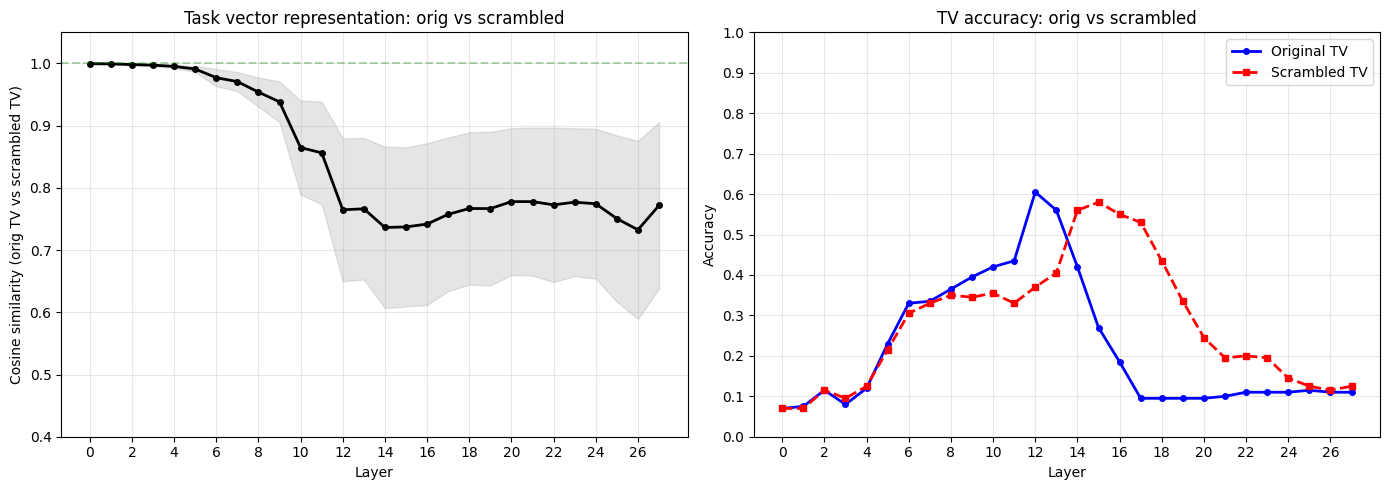


Layer   TV cos   Orig acc   Scram acc   Acc diff
----------------------------------------------
    0   0.9997      0.070       0.070     +0.000
    4   0.9953      0.120       0.125     -0.005
    8   0.9539      0.365       0.350     +0.015
   10   0.8647      0.420       0.355     +0.065
   12   0.7648      0.605       0.370     +0.235
   14   0.7364      0.420       0.560     -0.140
   16   0.7418      0.185       0.550     -0.365
   20   0.7779      0.095       0.245     -0.150
   24   0.7744      0.110       0.145     -0.035
   27   0.7718      0.110       0.125     -0.015

Lowest TV cosine: 0.7326 at layer 26
  Orig accuracy at that layer:  0.110
  Scram accuracy at that layer: 0.115


In [58]:
layers = list(range(n_layers))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: TV cosine across layers
ax = axes[0]
tv_cos_curve = [np.mean(tv_cos[l]) for l in layers]
tv_cos_std = [np.std(tv_cos[l]) for l in layers]
 
ax.plot(layers, tv_cos_curve, 'k-o', ms=4, lw=2)
ax.fill_between(layers,
                [m - s for m, s in zip(tv_cos_curve, tv_cos_std)],
                [m + s for m, s in zip(tv_cos_curve, tv_cos_std)],
                alpha=0.2, color='gray')
ax.axhline(1.0, ls='--', color='green', alpha=0.3)
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine similarity (orig TV vs scrambled TV)')
ax.set_title('Task vector representation: orig vs scrambled')
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
 
# Right: accuracy of both TVs across layers
ax = axes[1]
orig_acc = [np.mean(tv_orig_correct[l]) for l in layers]
scram_acc = [np.mean(tv_scram_correct[l]) for l in layers]
 
ax.plot(layers, orig_acc, 'b-o', ms=4, lw=2, label='Original TV')
ax.plot(layers, scram_acc, 'r--s', ms=4, lw=2, label='Scrambled TV')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('TV accuracy: orig vs scrambled')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
 
plt.tight_layout()
plt.show()
 
# Print side by side
print(f'\n{"Layer":>5s}  {"TV cos":>7s}  {"Orig acc":>9s}  {"Scram acc":>10s}  {"Acc diff":>9s}')
print('-' * 46)
for l in [0, 4, 8, 10, 12, 14, 16, 20, 24, 27]:
    print(f'{l:5d}  {np.mean(tv_cos[l]):7.4f}  {np.mean(tv_orig_correct[l]):9.3f}  '
          f'{np.mean(tv_scram_correct[l]):10.3f}  {np.mean(tv_orig_correct[l])-np.mean(tv_scram_correct[l]):+9.3f}')
 
# The punchline
min_cos_layer = min(range(n_layers), key=lambda l: np.mean(tv_cos[l]))
print(f'\nLowest TV cosine: {np.mean(tv_cos[min_cos_layer]):.4f} at layer {min_cos_layer}')
print(f'  Orig accuracy at that layer:  {np.mean(tv_orig_correct[min_cos_layer]):.3f}')
print(f'  Scram accuracy at that layer: {np.mean(tv_scram_correct[min_cos_layer]):.3f}')